In [1]:
import pandas as pd
import numpy as np
import glob
import dill
import os
import pingouin as pg
from scipy.optimize import minimize

import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.lines as mlines
import matplotlib.patches as mpatches

In high-sub-prototype (high variability) condition, each study item is a prototype of a sub catgory

In [ ]:
# # Load and automatically restore all variables to global namespace
# with open("Exp2_analysis.pkl", "rb") as f:
#     loaded_vars = dill.load(f)
#     globals().update(loaded_vars)

# print(f"Loaded {len(loaded_vars)} variables:", list(loaded_vars.keys()))

Loaded 1 variables: ['credited_subjects']


# Load Data

In [3]:
# Read Data
# Path to your Data folder
data_folder = 'Data'

# Get all JSON files in the folder
files = glob.glob(os.path.join(data_folder, '*.json'))

# Read and concatenate all files
data_frames = [pd.read_json(file) for file in files]
data_set = pd.concat(data_frames, ignore_index=True)
data_set

,width,height,webaudio,browser,browser_version,mobile,os,fullscreen,vsync_rate,webcam,...,response,task,image_id,filename,category,sub_category,sub_cat_item,object_type,block,correct
0,1470.0,801.0,1.0,chrome,154.0.0,0.0,Mac OS,1.0,60.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
485,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,s,test,155.0,I_Rhyolite_11.png,I,Rhyolite,11.0,novel,NaN,0.0
486,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,i,test,158.0,I_Rhyolite_14.png,I,Rhyolite,14.0,novel,NaN,1.0
487,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,s,test,358.0,S_Chert_06.png,S,Chert,6.0,novel,NaN,1.0
488,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,i,test,420.0,S_Rock Gypsum_04.png,S,Rock Gypsum,4.0,novel,NaN,0.0


In [4]:
# Only study and test trials, and only the columns we care about
data_set = data_set.loc[data_set['task'].isin(['study','test']),
                        ['trial_type','trial_index','block','date','time',
                         'subject_id','study_id','session_id',
                         'condition','cond_assign_source','rt',
                         'response','task','block',
                         'image_id','filename','category','sub_category','sub_cat_item',
                         'object_type','correct']]
data_set

,trial_type,trial_index,block,date,time,subject_id,study_id,session_id,condition,cond_assign_source,...,response,task,block,image_id,filename,category,sub_category,sub_cat_item,object_type,correct
5,categorize-image,5,1.0,2026-09-29,18:57:36,random_wdWgssUb,random_jtT7QeMq,random_Ix83ZaQS,high-sub-prototype,DataPipe,...,s,study,1.0,396.0,S_Dolomite_12.png,S,Dolomite,12.0,study,1.0
6,categorize-image,8,1.0,2026-09-29,18:57:36,random_wdWgssUb,random_jtT7QeMq,random_Ix83ZaQS,high-sub-prototype,DataPipe,...,i,study,1.0,6.0,I_Andesite_06.png,I,Andesite,6.0,study,1.0
7,categorize-image,11,1.0,2026-09-29,18:57:36,random_wdWgssUb,random_jtT7QeMq,random_Ix83ZaQS,high-sub-prototype,DataPipe,...,i,study,1.0,330.0,S_Bituminous Coal_10.png,S,Bituminous Coal,10.0,study,0.0
8,categorize-image,14,1.0,2026-09-29,18:57:36,random_wdWgssUb,random_jtT7QeMq,random_Ix83ZaQS,high-sub-prototype,DataPipe,...,i,study,1.0,119.0,I_Peridotite_07.png,I,Peridotite,7.0,study,1.0
9,categorize-image,17,1.0,2026-09-29,18:57:36,random_wdWgssUb,random_jtT7QeMq,random_Ix83ZaQS,high-sub-prototype,DataPipe,...,s,study,1.0,131.0,I_Pumice_03.png,I,Pumice,3.0,study,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
484,categorize-image,1431,NaN,2026-09-29,18:57:36,random_wdWgssUb,random_jtT7QeMq,random_Ix83ZaQS,high-sub-prototype,DataPipe,...,s,test,NaN,50.0,I_Gabbro_02.png,I,Gabbro,2.0,novel,0.0
485,categorize-image,1434,NaN,2026-09-29,18:57:36,random_wdWgssUb,random_jtT7QeMq,random_Ix83ZaQS,high-sub-prototype,DataPipe,...,s,test,NaN,155.0,I_Rhyolite_11.png,I,Rhyolite,11.0,novel,0.0
486,categorize-image,1437,NaN,2026-09-29,18:57:36,random_wdWgssUb,random_jtT7QeMq,random_Ix83ZaQS,high-sub-prototype,DataPipe,...,i,test,NaN,158.0,I_Rhyolite_14.png,I,Rhyolite,14.0,novel,1.0
487,categorize-image,1440,NaN,2026-09-29,18:57:36,random_wdWgssUb,random_jtT7QeMq,random_Ix83ZaQS,high-sub-prototype,DataPipe,...,s,test,NaN,358.0,S_Chert_06.png,S,Chert,6.0,novel,1.0


In [5]:
# Some recoding to make things easier to work with
data_set = data_set.rename(columns={'correct': 'is_correct',
                                    'task': 'phase'})
data_set['response'] = data_set['response'].str.upper()
data_set['trial_in_exp'] = (data_set
                            .sort_values(by=['subject_id', 'trial_index'])
                            .groupby(['subject_id'])
                            .cumcount().add(1)
                            )
data_set['object_type'] = data_set['object_type'].str.capitalize()
data_set['condition'] = data_set['condition'].str.capitalize()
data_set['condition'] = data_set['condition'].replace({'High-sub-prototype': 'High'})
data_set['phase'] = data_set['phase'].str.capitalize()

In [6]:
# Add a new column to indicate whether the novel item is in both conditions
novel_low_items = data_set.loc[(data_set['object_type'] =='Novel') & (data_set['condition'] == 'Low'), 'image_id'].unique()
novel_high_items = data_set.loc[(data_set['object_type'] =='Novel') & (data_set['condition'] == 'High'), 'image_id'].unique()
both_novel_items = list(set(novel_low_items) & set(novel_high_items)) # Overlap

data_set['object_type_detailed'] = data_set['object_type']
data_set.loc[data_set['image_id'].isin(both_novel_items) & (data_set['object_type'] == 'Novel'), 'object_type_detailed'] = 'Novel_Both'
data_set

,trial_type,trial_index,block,date,time,subject_id,study_id,session_id,condition,cond_assign_source,...,block,image_id,filename,category,sub_category,sub_cat_item,object_type,is_correct,trial_in_exp,object_type_detailed
5,categorize-image,5,1.0,2026-09-29,18:57:36,random_wdWgssUb,random_jtT7QeMq,random_Ix83ZaQS,High,DataPipe,...,1.0,396.0,S_Dolomite_12.png,S,Dolomite,12.0,Study,1.0,1,Study
6,categorize-image,8,1.0,2026-09-29,18:57:36,random_wdWgssUb,random_jtT7QeMq,random_Ix83ZaQS,High,DataPipe,...,1.0,6.0,I_Andesite_06.png,I,Andesite,6.0,Study,1.0,2,Study
7,categorize-image,11,1.0,2026-09-29,18:57:36,random_wdWgssUb,random_jtT7QeMq,random_Ix83ZaQS,High,DataPipe,...,1.0,330.0,S_Bituminous Coal_10.png,S,Bituminous Coal,10.0,Study,0.0,3,Study
8,categorize-image,14,1.0,2026-09-29,18:57:36,random_wdWgssUb,random_jtT7QeMq,random_Ix83ZaQS,High,DataPipe,...,1.0,119.0,I_Peridotite_07.png,I,Peridotite,7.0,Study,1.0,4,Study
9,categorize-image,17,1.0,2026-09-29,18:57:36,random_wdWgssUb,random_jtT7QeMq,random_Ix83ZaQS,High,DataPipe,...,1.0,131.0,I_Pumice_03.png,I,Pumice,3.0,Study,0.0,5,Study
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
484,categorize-image,1431,NaN,2026-09-29,18:57:36,random_wdWgssUb,random_jtT7QeMq,random_Ix83ZaQS,High,DataPipe,...,NaN,50.0,I_Gabbro_02.png,I,Gabbro,2.0,Novel,0.0,476,Novel
485,categorize-image,1434,NaN,2026-09-29,18:57:36,random_wdWgssUb,random_jtT7QeMq,random_Ix83ZaQS,High,DataPipe,...,NaN,155.0,I_Rhyolite_11.png,I,Rhyolite,11.0,Novel,0.0,477,Novel
486,categorize-image,1437,NaN,2026-09-29,18:57:36,random_wdWgssUb,random_jtT7QeMq,random_Ix83ZaQS,High,DataPipe,...,NaN,158.0,I_Rhyolite_14.png,I,Rhyolite,14.0,Novel,1.0,478,Novel
487,categorize-image,1440,NaN,2026-09-29,18:57:36,random_wdWgssUb,random_jtT7QeMq,random_Ix83ZaQS,High,DataPipe,...,NaN,358.0,S_Chert_06.png,S,Chert,6.0,Novel,1.0,479,Novel


In [7]:
# Variable type conversions for memory efficiency and easier analysis
data_set = data_set.astype({'subject_id': 'string',
                            'condition': 'category',
                            'response': 'category', 
                            'phase': 'category', 
                            'category': 'category',
                            'object_type': 'category',
                            'object_type_detailed': 'category',
                            'is_correct': 'bool'}).reset_index(drop=True)
data_set

,trial_type,trial_index,block,date,time,subject_id,study_id,session_id,condition,cond_assign_source,...,block,image_id,filename,category,sub_category,sub_cat_item,object_type,is_correct,trial_in_exp,object_type_detailed
0,categorize-image,5,1.0,2026-09-29,18:57:36,random_wdWgssUb,random_jtT7QeMq,random_Ix83ZaQS,High,DataPipe,...,1.0,396.0,S_Dolomite_12.png,S,Dolomite,12.0,Study,True,1,Study
1,categorize-image,8,1.0,2026-09-29,18:57:36,random_wdWgssUb,random_jtT7QeMq,random_Ix83ZaQS,High,DataPipe,...,1.0,6.0,I_Andesite_06.png,I,Andesite,6.0,Study,True,2,Study
2,categorize-image,11,1.0,2026-09-29,18:57:36,random_wdWgssUb,random_jtT7QeMq,random_Ix83ZaQS,High,DataPipe,...,1.0,330.0,S_Bituminous Coal_10.png,S,Bituminous Coal,10.0,Study,False,3,Study
3,categorize-image,14,1.0,2026-09-29,18:57:36,random_wdWgssUb,random_jtT7QeMq,random_Ix83ZaQS,High,DataPipe,...,1.0,119.0,I_Peridotite_07.png,I,Peridotite,7.0,Study,True,4,Study
4,categorize-image,17,1.0,2026-09-29,18:57:36,random_wdWgssUb,random_jtT7QeMq,random_Ix83ZaQS,High,DataPipe,...,1.0,131.0,I_Pumice_03.png,I,Pumice,3.0,Study,False,5,Study
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
475,categorize-image,1431,NaN,2026-09-29,18:57:36,random_wdWgssUb,random_jtT7QeMq,random_Ix83ZaQS,High,DataPipe,...,NaN,50.0,I_Gabbro_02.png,I,Gabbro,2.0,Novel,False,476,Novel
476,categorize-image,1434,NaN,2026-09-29,18:57:36,random_wdWgssUb,random_jtT7QeMq,random_Ix83ZaQS,High,DataPipe,...,NaN,155.0,I_Rhyolite_11.png,I,Rhyolite,11.0,Novel,False,477,Novel
477,categorize-image,1437,NaN,2026-09-29,18:57:36,random_wdWgssUb,random_jtT7QeMq,random_Ix83ZaQS,High,DataPipe,...,NaN,158.0,I_Rhyolite_14.png,I,Rhyolite,14.0,Novel,True,478,Novel
478,categorize-image,1440,NaN,2026-09-29,18:57:36,random_wdWgssUb,random_jtT7QeMq,random_Ix83ZaQS,High,DataPipe,...,NaN,358.0,S_Chert_06.png,S,Chert,6.0,Novel,True,479,Novel


# Performance by ID

In [8]:
# performance for every subject
performance_by_id = (data_set[data_set['phase']=='Test']
 .groupby(['condition','subject_id'], observed=True)
 .agg(
     total_trials=('response','size'),
     total_cor=('is_correct', lambda x: (x==True).sum()),
     mean_RT = ('rt', 'mean')
 )
 .reset_index()
 .assign(prop_corr = lambda df: df['total_cor'] / df['total_trials'])
 )
performance_by_id

,condition,subject_id,total_trials,total_cor,mean_RT,prop_corr
0,High,random_wdWgssUb,320,231,2556.2625,0.721875


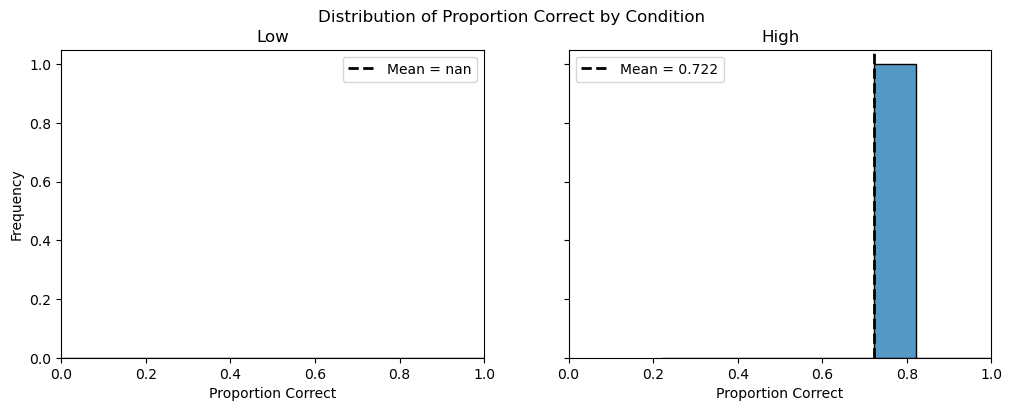

In [9]:
# Prop correct by condition
fig, axes = plt.subplots(1, 2, figsize=(12, 4), 
                         sharex = True, sharey=True)

dat_low = performance_by_id[performance_by_id['condition']=='Low']
dat_high = performance_by_id[performance_by_id['condition']=='High']

for ax, dat in zip(axes, [dat_low, dat_high]):
    sns.histplot(data=dat, x='prop_corr', bins=10, ax=ax)
    ax.axvline(dat['prop_corr'].mean(), 
               linestyle="--", color='black', linewidth=2, 
               label = f"Mean = {dat['prop_corr'].mean():.3f}")
    ax.set(xlabel='Proportion Correct', ylabel='Frequency', 
           title='Low' if dat is dat_low else 'High')
    ax.legend()
    ax.set_xlim(0, 1)

plt.suptitle("Distribution of Proportion Correct by Condition")
plt.show()

## Grant credit

Give credit to those who completed the study. Give bonus to those in top 25% based on accuracy

In [10]:
all_subjects = performance_by_id['subject_id'].unique()

In [11]:
# Not credited subjects
not_credited_yet = [id for id in all_subjects if id not in credited_subjects]

print(not_credited_yet)

NameError: name 'credited_subjects' is not defined

In [ ]:
# # Select subjects who have not received credit yet
# not_credited_performance = performance_by_id[performance_by_id['subject_id'].isin(not_credited_yet)]

# # Upper 75th percentile of proportion correct for each condition (among those who have NOT received credit yet)
# top_quarter = not_credited_performance.groupby('condition', observed=True)['prop_corr'].quantile(0.75)
# not_credited_performance['is_bonus'] = not_credited_performance.apply(
#     lambda row: row['prop_corr'] >= top_quarter[row['condition']],
#     axis=1)

# # Show subjects who have not received credit yet, and those who are eligible for bonus credit
# print(f'All subjects (total={len(not_credited_performance.subject_id.tolist())}): {not_credited_performance.subject_id.tolist()}')
# print(f'\nBonus subjects (total={len(not_credited_performance[not_credited_performance.is_bonus].subject_id.tolist())}): {not_credited_performance[not_credited_performance.is_bonus].subject_id.tolist()}')

По-хорошему, нужно ещё этим бонус заплатить: 6a0317409039cf59e9efa6fa, 6a0e594437815727fefde9b9

In [ ]:
# Total number of subjects
print(f'Total number of subjects: {len(all_subjects)}')
print(f'New subjects: {len(not_credited_yet)}')

Total number of subjects: 152
New subjects: 0


In [ ]:
# Those who has received participation credit
credited_subjects = all_subjects.copy()

In [ ]:
# N subjects by condition
performance_by_id.groupby('condition', observed=True)['prop_corr'].describe().round(3)

,count,mean,std,min,25%,50%,75%,max
condition,,,,,,,,
High,71.0,0.662,0.084,0.462,0.598,0.672,0.723,0.822
Low,81.0,0.670,0.045,0.534,0.644,0.672,0.703,0.747


In [ ]:
# how many times each subject appears in the dataset (should be 480 for all subjects)
(data_set.subject_id.value_counts()/480).sort_values(ascending=False)

subject_id
65fbb4220141f00a2ed68e4b    1.0
6a01d033635a276a9d544a97    1.0
94374                       1.0
95908                       1.0
94096                       1.0
                           ... 
97101                       1.0
6931e8404b624d619bb12ce7    1.0
5c3377fb04f29e0001104681    1.0
95522                       1.0
94831                       1.0
Name: count, Length: 152, dtype: Float64

## Filter IDs

In [14]:
# exclude lowest 10% of subjects by accuracy and highest 10% by RT in each condition
threshold_acc = performance_by_id.groupby('condition', observed=True)['prop_corr'].quantile(0.1)
threshold_rt = performance_by_id.groupby('condition', observed=True)['mean_RT'].quantile(0.9)

print(f'Accuracy thresholds by condition:\n{threshold_acc}\n')
print(f'Reaction time thresholds by condition:\n{threshold_rt}\n')

# performance_by_id['is_good_subj'] = performance_by_id.apply(lambda row: (row['prop_corr'] >= threshold_acc[row['condition']]) & 
#                                                             (row['mean_RT'] <= threshold_rt[row['condition']]), 
#                                                             axis=1)
performance_by_id['is_good_subj'] = True # change later! Now keep all subjects for analysis

print(f'Proportion of good subjects: {performance_by_id.is_good_subj.value_counts()[True] / performance_by_id.shape[0]:.2%}')

Accuracy thresholds by condition:
condition
High    0.721875
Name: prop_corr, dtype: float64

Reaction time thresholds by condition:
condition
High    2556.2625
Name: mean_RT, dtype: float64

Proportion of good subjects: 100.00%


In [15]:
# N subjects by condition and good/bad subject
performance_by_id.groupby('condition', as_index=False).is_good_subj.value_counts()

,condition,is_good_subj,count
0,High,True,1


In [16]:
# Merge it with the main data set
data_set = pd.merge(
    data_set,
    performance_by_id.loc[:,['condition', 'subject_id','is_good_subj']],
    how='left', on=['condition', 'subject_id']
)

# use only good subjects
filtered_data = data_set.loc[data_set['is_good_subj']==True]
filtered_data

,trial_type,trial_index,block,date,time,subject_id,study_id,session_id,condition,cond_assign_source,...,image_id,filename,category,sub_category,sub_cat_item,object_type,is_correct,trial_in_exp,object_type_detailed,is_good_subj
0,categorize-image,5,1.0,2026-09-29,18:57:36,random_wdWgssUb,random_jtT7QeMq,random_Ix83ZaQS,High,DataPipe,...,396.0,S_Dolomite_12.png,S,Dolomite,12.0,Study,True,1,Study,True
1,categorize-image,8,1.0,2026-09-29,18:57:36,random_wdWgssUb,random_jtT7QeMq,random_Ix83ZaQS,High,DataPipe,...,6.0,I_Andesite_06.png,I,Andesite,6.0,Study,True,2,Study,True
2,categorize-image,11,1.0,2026-09-29,18:57:36,random_wdWgssUb,random_jtT7QeMq,random_Ix83ZaQS,High,DataPipe,...,330.0,S_Bituminous Coal_10.png,S,Bituminous Coal,10.0,Study,False,3,Study,True
3,categorize-image,14,1.0,2026-09-29,18:57:36,random_wdWgssUb,random_jtT7QeMq,random_Ix83ZaQS,High,DataPipe,...,119.0,I_Peridotite_07.png,I,Peridotite,7.0,Study,True,4,Study,True
4,categorize-image,17,1.0,2026-09-29,18:57:36,random_wdWgssUb,random_jtT7QeMq,random_Ix83ZaQS,High,DataPipe,...,131.0,I_Pumice_03.png,I,Pumice,3.0,Study,False,5,Study,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
475,categorize-image,1431,NaN,2026-09-29,18:57:36,random_wdWgssUb,random_jtT7QeMq,random_Ix83ZaQS,High,DataPipe,...,50.0,I_Gabbro_02.png,I,Gabbro,2.0,Novel,False,476,Novel,True
476,categorize-image,1434,NaN,2026-09-29,18:57:36,random_wdWgssUb,random_jtT7QeMq,random_Ix83ZaQS,High,DataPipe,...,155.0,I_Rhyolite_11.png,I,Rhyolite,11.0,Novel,False,477,Novel,True
477,categorize-image,1437,NaN,2026-09-29,18:57:36,random_wdWgssUb,random_jtT7QeMq,random_Ix83ZaQS,High,DataPipe,...,158.0,I_Rhyolite_14.png,I,Rhyolite,14.0,Novel,True,478,Novel,True
478,categorize-image,1440,NaN,2026-09-29,18:57:36,random_wdWgssUb,random_jtT7QeMq,random_Ix83ZaQS,High,DataPipe,...,358.0,S_Chert_06.png,S,Chert,6.0,Novel,True,479,Novel,True


# Accuracy Distribution in each Condition

In [19]:
acc_by_ID_df = (filtered_data
 .groupby(['condition', 'subject_id', 'object_type_detailed'], observed=True)
 .agg({'is_correct': 'mean', 'rt': 'mean'})
 .reset_index()
 .rename(columns={'is_correct': 'accuracy', 'rt': 'mean_RT'})
 )
acc_by_ID_df

,condition,subject_id,object_type_detailed,accuracy,mean_RT
0,High,random_wdWgssUb,Novel,0.713333,2627.900000
1,High,random_wdWgssUb,Study,0.788889,1619.433333


## Prop Correct

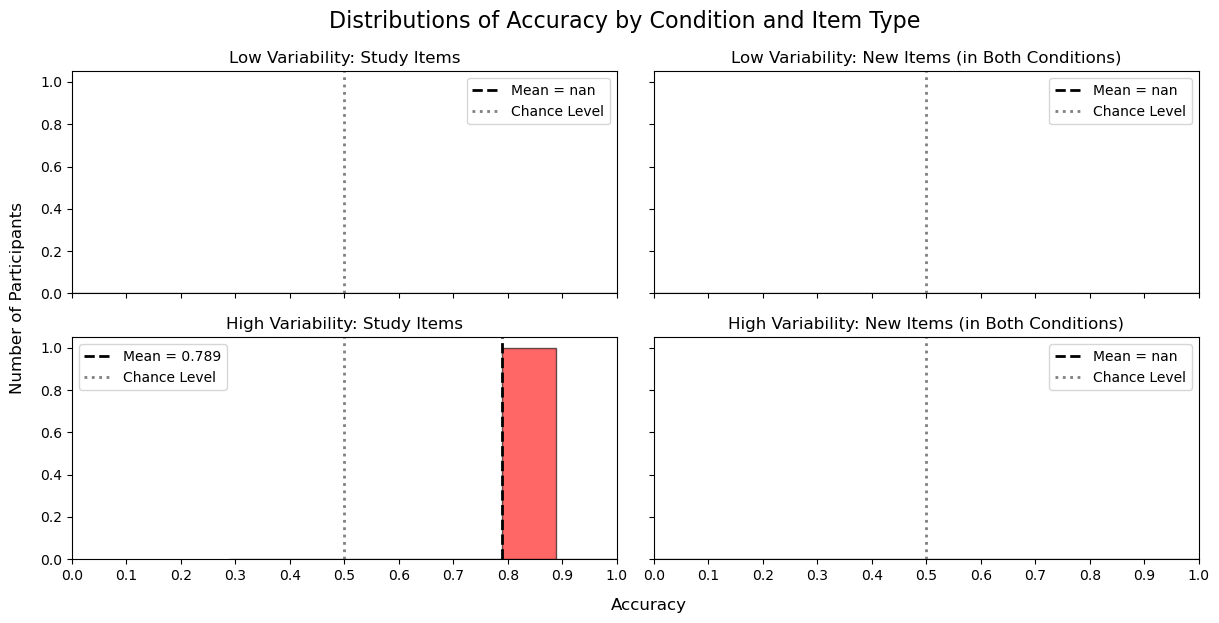

In [20]:
# n_bins = 15
# n_subj = 20

fig, axes = plt.subplots(2, 2, figsize=(12, 6), sharex=True, sharey=True)

conditions = [('Low', 'blue'), ('High', 'red')]
item_types = [('Study', 'Study Items'), ('Novel_Both', 'New Items (in Both Conditions)')]

for row, (condition, color) in enumerate(conditions):
    for col, (item_type, item_label) in enumerate(item_types):
        ax = axes[row, col]
        
        data = acc_by_ID_df.loc[
            (acc_by_ID_df['condition'] == condition) & 
            (acc_by_ID_df['object_type_detailed'] == item_type), 
            'accuracy'
        ]
        mean_val = data.mean()
        
        ax.hist(data, #bins=n_bins, 
                color=color, alpha=0.6, edgecolor='black')
        ax.set_title(f'{condition} Variability: {item_label}')
        ax.set_xlim(0, 1)
        #ax.set_ylim(0, n_subj)
        ax.set_xticks(np.arange(0, 1.1, 0.1))
        ax.axvline(x=mean_val, color='black', linestyle='dashed', linewidth=2,
                   label=f'Mean = {mean_val:.3f}')
        ax.axvline(x=1/2, color='gray', linestyle='dotted', linewidth=2, label='Chance Level')
        ax.legend()

fig.text(0.52, 0, 'Accuracy', ha='center', va='top', fontsize=12)
fig.text(0, 0.5, 'Number of Participants', ha='right', va='center', rotation='vertical', fontsize=12)
fig.suptitle('Distributions of Accuracy by Condition and Item Type', fontsize=16)
plt.tight_layout()
plt.show()

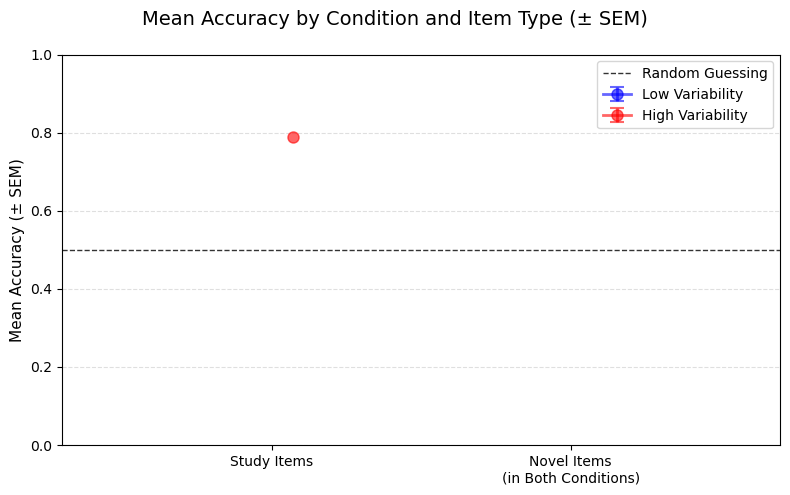

In [21]:
# Same plot but with error bars instead of histograms
fig, ax = plt.subplots(1, 1, figsize=(8, 5))

conditions  = ['Low', 'High']
item_types  = ['Study', 'Novel_Both']
colors_cond = {'Low': 'blue', 'High': 'red'}
dodge       = {'Low': -0.07, 'High': 0.07}  
x_positions = {item: i for i, item in enumerate(item_types)}

for condition in conditions:
    means, sems, xs = [], [], []
    for item_type in item_types:
        subset = acc_by_ID_df.loc[
            (acc_by_ID_df['object_type_detailed'] == item_type) &
            (acc_by_ID_df['condition'] == condition)
        ]
        means.append(subset['accuracy'].mean())
        sems.append(subset['accuracy'].sem())
        xs.append(x_positions[item_type] + dodge[condition])

    ax.errorbar(
        xs, means, yerr=sems,
        label=f'{condition} Variability',
        color=colors_cond[condition],
        marker='o', markersize=8,
        linewidth=2, capsize=5, capthick=1.5, alpha=0.6
    )

ax.axhline(1/2, color='black', alpha=0.8, ls='--', lw=1, label='Random Guessing')
ax.set_xticks(range(len(item_types)))
ax.set_xticklabels(['Study Items', 'Novel Items\n(in Both Conditions)'])
ax.set_xlim(-0.7, len(item_types)-0.3)
ax.set_ylim(0., 1.0)
ax.set_yticks(np.arange(0.0, 1.01, 0.2))
ax.set_ylabel('Mean Accuracy (± SEM)', fontsize=11)
ax.legend(fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.suptitle('Mean Accuracy by Condition and Item Type (± SEM)', fontsize=14)
plt.tight_layout()
plt.show()

In [22]:
# ANOVA
aov = pg.mixed_anova(
    data=acc_by_ID_df,
    dv="accuracy",
    between="condition",
    within="object_type_detailed",
    subject="subject_id",
)
aov

/opt/anaconda3/envs/variability-exp/lib/python3.12/site-packages/pingouin/parametric.py:574: RuntimeWarning: invalid value encountered in scalar divide
  ms_reswith = ss_reswith / ddof2
/opt/anaconda3/envs/variability-exp/lib/python3.12/site-packages/pandas/core/frame.py:13288: RuntimeWarning: Degrees of freedom <= 0 for slice
  base_cov = np.cov(mat.T, ddof=ddof)
/opt/anaconda3/envs/variability-exp/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2888: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/opt/anaconda3/envs/variability-exp/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2888: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)
/opt/anaconda3/envs/variability-exp/lib/python3.12/site-packages/pingouin/parametric.py:1006: RuntimeWarning: invalid value encountered in scalar divide
  msbetween = ssbetween / ddof1
/opt/anaconda3/envs/variability-exp/lib/python3.12/site-packages/pingou

,Source,SS,DF1,DF2,MS,np2,eps
0,condition,0.000000,0,0,NaN,NaN,NaN
1,object_type_detailed,0.002854,1,0,0.002854,1.0,1.0
2,Interaction,0.000000,0,0,NaN,NaN,NaN


Post-hoc pairwise tests with Bonferroni correction

In [23]:
# --- set these to your actual level labels ---
STUDY, NOVEL = "Study", "Novel_Both"   # object_type_detailed
LOW,   HIGH  = "Low", "High"           # condition

# one row per subject, columns = object types
wide = (acc_by_ID_df
        .pivot_table(index=["subject_id", "condition"],
                     columns="object_type_detailed",
                     values="accuracy")
        .reset_index()
        .dropna(subset=[STUDY, NOVEL]))   # only Study + Novel_Both, NOT "Novel"

res = []

# 1) study: low vs high  (between -> Welch)
res.append(("Study: low vs high (between)",
    pg.ttest(wide.loc[wide.condition==LOW,  STUDY],
             wide.loc[wide.condition==HIGH, STUDY],
             paired=False, correction=True)))   # correction=True => Welch

# 2) novel: low vs high  (between -> Welch)
res.append(("Novel: low vs high (between)",
    pg.ttest(wide.loc[wide.condition==LOW,  NOVEL],
             wide.loc[wide.condition==HIGH, NOVEL],
             paired=False, correction=True)))

# 3) low: study vs novel  (within -> paired)
sub = wide[wide.condition==LOW]
res.append(("Low: study vs novel (within)",
    pg.ttest(sub[STUDY], sub[NOVEL], paired=True)))

# 4) high: study vs novel  (within -> paired)
sub = wide[wide.condition==HIGH]
res.append(("High: study vs novel (within)",
    pg.ttest(sub[STUDY], sub[NOVEL], paired=True)))

tbl = pd.DataFrame([{
    "contrast": name,
    "T":       r["T"].iloc[0],
    "dof":     r["dof"].iloc[0],
    "p_unc":   r["p_val"].iloc[0],
    "cohen_d": r["cohen_d"].iloc[0],
} for name, r in res])

tbl["p_bonf"] = np.minimum(tbl["p_unc"] * len(tbl), 1.0)
tbl.round(4)

KeyError: ['Novel_Both']

# Condition Accuracy on Number of Training Items

Count how many instances from the same `SubCategory` were there in the study phase.

So, that's ok that a an item which is novel in both conditions has >0 train_count. This is because this exact item was never studied but objects from the same subcategory were!

In [24]:
# Number of Study items per (condition, subject, category, sub_category), divided by repetitions
def compute_train_counts(data_set, n_reps=8):
    return (data_set.loc[data_set['phase'] == 'Study']
            .groupby(['condition', 'subject_id', 'category'], observed=True)['sub_category']
            .value_counts()
            .reset_index(name='train_count')
            .assign(train_count=lambda df: df['train_count'] / n_reps))

In [25]:
# Left-merge train counts into df and fill missing with 0
def add_train_counts(df, train_counts):
    out = pd.merge(df, train_counts, how='left',
                   on=['condition', 'subject_id', 'category', 'sub_category'])
    out['train_count'] = out['train_count'].fillna(0)
    return out

In [26]:
# Plot mean accuracy (± SEM across subjects) by condition, item type and train count.
# value_col  : 'is_correct' for observed data, or the column with model predictions (per-trial predicted probability of a correct response)
def plot_accuracy_by_train_count(df, value_col='is_correct', model_name=None,
                                 conditions=('Low', 'High'),
                                 item_types=(('Study', 'Study Items'),
                                             ('Novel_Both', 'Novel Items (Both Conditions)')),
                                 colors=None, dodge=None, xticks=range(0, 6),
                                 figsize=(12, 5)):
    colors = colors or {'Low': 'blue', 'High': 'red'}
    dodge = dodge or {'Low': -0.07, 'High': 0.07}
    source = 'Observed' if model_name is None else model_name

    # Subject-level means
    by_subj = (df.groupby(['condition', 'subject_id', 'object_type_detailed', 'train_count'],
                          observed=True)[value_col]
                 .mean()
                 .reset_index(name='accuracy'))

    fig, axes = plt.subplots(1, len(item_types), figsize=figsize, sharey=True)
    axes = np.atleast_1d(axes)

    for ax, (item_type, item_label) in zip(axes, item_types):
        for condition in conditions:
            subset = by_subj[(by_subj['condition'] == condition) &
                             (by_subj['object_type_detailed'] == item_type)]
            stats = (subset.groupby('train_count')['accuracy']
                           .agg(mean='mean', sem='sem')
                           .reset_index())

            ax.errorbar(stats['train_count'] + dodge[condition], stats['mean'],
                        yerr=stats['sem'], label=f'{condition} Variability',
                        color=colors[condition], alpha=0.6, marker='o', markersize=5,
                        linewidth=2, capsize=5, capthick=1.5)

        ax.axhline(y=0.5, color='gray', linestyle='dotted', linewidth=1.5, label='Chance Level')
        ax.set_title(item_label, fontsize=13)
        ax.set_xticks(list(xticks))
        ax.set_ylim(0, 1)
        ax.set_yticks(np.arange(0, 1.1, 0.1))
        ax.legend(fontsize=9)
        ax.grid(axis='y', linestyle='--', alpha=0.4)

    ylabel = 'Mean Accuracy (± SEM)' if model_name is None else 'Mean Predicted Accuracy (± SEM)'
    axes[0].set_ylabel(ylabel, fontsize=12)
    fig.text(0.5, 0.0, 'Number of Training Items from the Same Sub-Categories',
             ha='center', va='top', fontsize=12)
    fig.suptitle(f'Mean Accuracy by Condition and Training Count — {source}', fontsize=14)
    plt.tight_layout()
    plt.show()

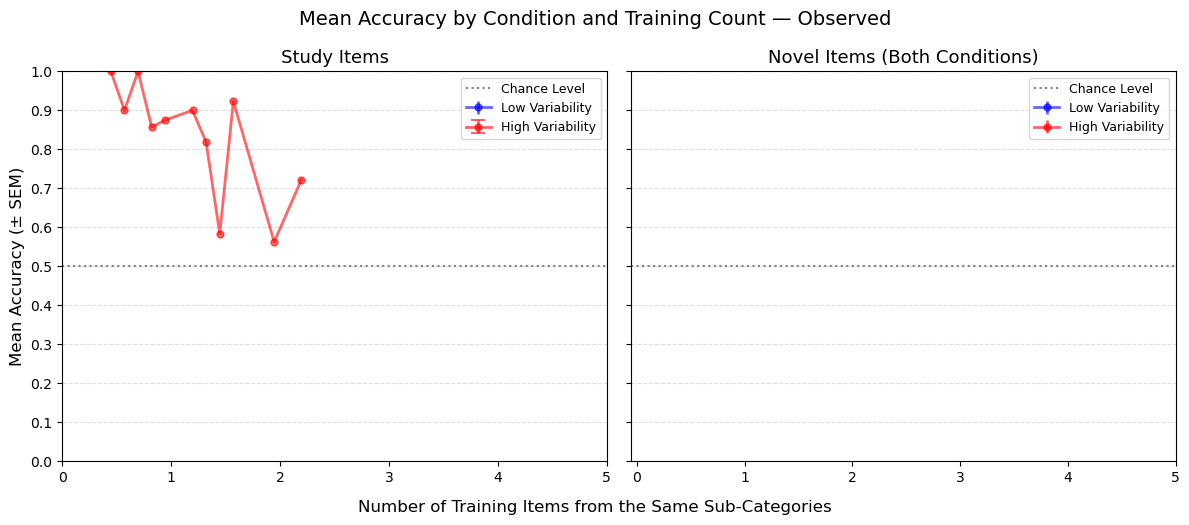

In [27]:
train_counts = compute_train_counts(data_set)
data_set = add_train_counts(data_set, train_counts)
filtered_data = add_train_counts(filtered_data, train_counts)

# Observed
plot_accuracy_by_train_count(filtered_data)

In [28]:
plot_accuracy_by_train_count(filtered_data_test, value_col='pred_model_A', model_name='Model A'); plt.show()

NameError: name 'filtered_data_test' is not defined

# Learning curve (rolling avg)

In [12]:
conditions = ['Low', 'High']
cond_colors = {'Low': 'blue', 'High': 'red'}
window = 50
study_end = 161

data_roll = filtered_data.sort_values(['subject_id', 'trial_in_exp']).copy()
data_roll['roll'] = (data_roll.groupby('subject_id')['is_correct']
                              .transform(lambda s: s.rolling(window, min_periods=1).mean()))

fig, ax = plt.subplots(1, 1, figsize=(9, 5))

ax.axvspan(1, study_end, color='0.85', alpha=0.6, zorder=0)
ax.axhline(0.5, color='0.4', alpha=0.8, ls='--', lw=1, zorder=1)

xmins, xmaxs = [], []
for cond in conditions:
    sub   = data_roll[data_roll['condition'] == cond]
    curve = sub.groupby('trial_in_exp')['roll'].mean()
    xmins.append(curve.index.min())
    xmaxs.append(curve.index.max())

    sns.lineplot(x=curve.index, y=curve.values, color=cond_colors[cond],
                 alpha=0.6, lw=2, ax=ax, zorder=2, label=cond)

ax.text(study_end / 2, 0.1, 'Study phase',
        transform=ax.get_xaxis_transform(),
        fontsize=11, color='0.3', ha='center', va='bottom')

ax.set_xlabel('Trial', fontsize=12)
ax.set_ylabel('Rolling Average Correct', fontsize=12)
ax.set_xlim(min(xmins), max(xmaxs))
ax.set_xticks(np.arange(1, 481, 50))
ax.set_ylim(0.0, 1.0)
ax.set_yticks(np.arange(0, 1.01, 0.2))

ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', alpha=0.25)
leg = ax.legend(fontsize=11, frameon=False, loc='lower right',
                title='Variability condition', 
                title_fontsize=11)
leg.get_title().set_fontweight('bold')

plt.title(f'Rolling Average Correct\n(window size = {window} trials)', 
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

NameError: name 'filtered_data' is not defined

## Adaptive-sampling caveat for the study-phase learning curve

The rolling-average plot above (accuracy by raw trial position) assumed that the mix of items shown at any point in the study phase was the same regardless of how far along the participant was — true for the old, non-adaptive design.

Exp 3's study phase samples items adaptively: from block 2 onward, items the participant is still getting wrong are shown more often, and items they've mastered are shown less often (never zero). That means the difficulty of what's on screen keeps adjusting to chase the participant's current weak spots, which can flatten or even depress a raw accuracy-by-trial-position curve independent of whether real learning is happening — a moving-target confound.

Two alternatives that aren't confounded this way:
1. **By item repetition count** — accuracy as a function of "how many times has this specific item been shown to this participant", instead of absolute trial position.
2. **Recency-weighted accuracy by block** — the same quantity the adaptive sampler itself computes to pick each block's stimuli (`recency_lambda = 0.7` in `src/config.js`), aggregated across items per block.

The test phase is unaffected by any of this — it always draws from a fixed, non-adaptive stimulus set, so the original rolling-average approach remains valid there.


### Approach 1 — accuracy by item repetition count


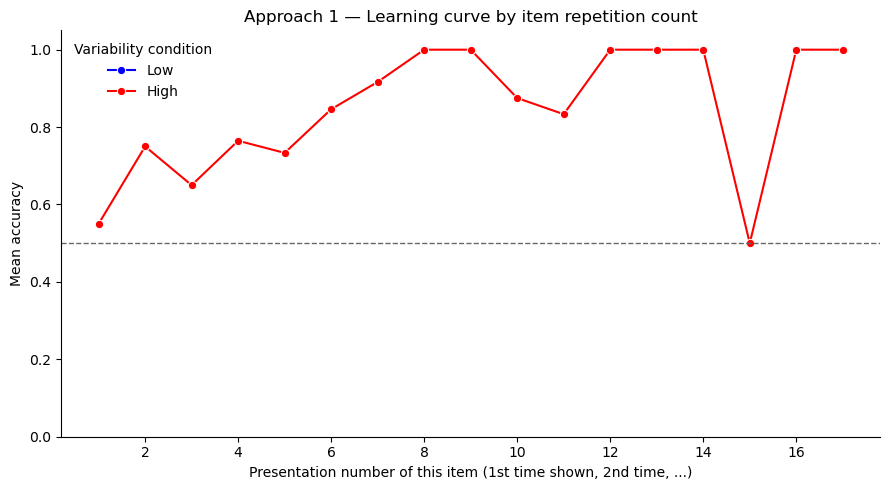

condition,High
presentation_n,
1,20
2,20
3,20
4,17
5,15
6,13
7,12
8,9
9,9


In [17]:
# Approach 1: accuracy by the n-th presentation of EACH item (per subject),
# instead of raw trial position. Not confounded by adaptive resampling, since
# it conditions on "how many times has this item been shown to this
# participant so far", not on absolute trial/block number.

study_only = filtered_data.loc[filtered_data['phase'] == 'Study'].copy()
study_only = study_only.sort_values(['subject_id', 'image_id', 'trial_in_exp'])
study_only['presentation_n'] = (study_only
                                 .groupby(['subject_id', 'image_id'])
                                 .cumcount().add(1))

fig, ax = plt.subplots(figsize=(9, 5))
for cond in conditions:
    sub = study_only[study_only['condition'] == cond]
    by_pres = (sub.groupby('presentation_n')['is_correct']
                  .agg(['mean', 'count'])
                  .reset_index())
    sns.lineplot(data=by_pres, x='presentation_n', y='mean',
                 marker='o', color=cond_colors[cond], label=cond, ax=ax)

ax.axhline(0.5, color='0.4', ls='--', lw=1)
ax.set_xlabel('Presentation number of this item (1st time shown, 2nd time, ...)')
ax.set_ylabel('Mean accuracy')
ax.set_ylim(0, 1.05)
ax.set_title('Approach 1 — Learning curve by item repetition count')
ax.spines[['top', 'right']].set_visible(False)
leg = ax.legend(frameon=False, title='Variability condition')
plt.tight_layout()
plt.show()

# Sample size behind each point (small-n tail at high repetition counts should
# be read with caution, especially with few subjects)
study_only.groupby(['condition', 'presentation_n'])['is_correct'].count().unstack(0)


### Approach 2 — recency-weighted accuracy by block

Same formula the adaptive sampler uses between blocks: for each item, recent blocks count more than older ones (`recency_lambda`), with repeated presentations *within* one block averaged into a single value first (mean-per-block rule) so a heavily-repeated item doesn't dominate the estimate.


In [22]:
filtered_data

,trial_type,trial_index,block,date,time,subject_id,study_id,session_id,condition,cond_assign_source,...,image_id,filename,category,sub_category,sub_cat_item,object_type,is_correct,trial_in_exp,object_type_detailed,is_good_subj
0,categorize-image,5,1.0,2026-09-29,18:57:36,random_wdWgssUb,random_jtT7QeMq,random_Ix83ZaQS,High,DataPipe,...,396.0,S_Dolomite_12.png,S,Dolomite,12.0,Study,True,1,Study,True
1,categorize-image,8,1.0,2026-09-29,18:57:36,random_wdWgssUb,random_jtT7QeMq,random_Ix83ZaQS,High,DataPipe,...,6.0,I_Andesite_06.png,I,Andesite,6.0,Study,True,2,Study,True
2,categorize-image,11,1.0,2026-09-29,18:57:36,random_wdWgssUb,random_jtT7QeMq,random_Ix83ZaQS,High,DataPipe,...,330.0,S_Bituminous Coal_10.png,S,Bituminous Coal,10.0,Study,False,3,Study,True
3,categorize-image,14,1.0,2026-09-29,18:57:36,random_wdWgssUb,random_jtT7QeMq,random_Ix83ZaQS,High,DataPipe,...,119.0,I_Peridotite_07.png,I,Peridotite,7.0,Study,True,4,Study,True
4,categorize-image,17,1.0,2026-09-29,18:57:36,random_wdWgssUb,random_jtT7QeMq,random_Ix83ZaQS,High,DataPipe,...,131.0,I_Pumice_03.png,I,Pumice,3.0,Study,False,5,Study,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
475,categorize-image,1431,NaN,2026-09-29,18:57:36,random_wdWgssUb,random_jtT7QeMq,random_Ix83ZaQS,High,DataPipe,...,50.0,I_Gabbro_02.png,I,Gabbro,2.0,Novel,False,476,Novel,True
476,categorize-image,1434,NaN,2026-09-29,18:57:36,random_wdWgssUb,random_jtT7QeMq,random_Ix83ZaQS,High,DataPipe,...,155.0,I_Rhyolite_11.png,I,Rhyolite,11.0,Novel,False,477,Novel,True
477,categorize-image,1437,NaN,2026-09-29,18:57:36,random_wdWgssUb,random_jtT7QeMq,random_Ix83ZaQS,High,DataPipe,...,158.0,I_Rhyolite_14.png,I,Rhyolite,14.0,Novel,True,478,Novel,True
478,categorize-image,1440,NaN,2026-09-29,18:57:36,random_wdWgssUb,random_jtT7QeMq,random_Ix83ZaQS,High,DataPipe,...,358.0,S_Chert_06.png,S,Chert,6.0,Novel,True,479,Novel,True


In [24]:
study_only

,trial_type,trial_index,block,date,time,subject_id,study_id,session_id,condition,cond_assign_source,...,filename,category,sub_category,sub_cat_item,object_type,is_correct,trial_in_exp,object_type_detailed,is_good_subj,presentation_n
1,categorize-image,8,1.0,2026-09-29,18:57:36,random_wdWgssUb,random_jtT7QeMq,random_Ix83ZaQS,High,DataPipe,...,I_Andesite_06.png,I,Andesite,6.0,Study,True,2,Study,True,1
25,categorize-image,80,2.0,2026-09-29,18:57:36,random_wdWgssUb,random_jtT7QeMq,random_Ix83ZaQS,High,DataPipe,...,I_Andesite_06.png,I,Andesite,6.0,Study,True,26,Study,True,2
53,categorize-image,164,3.0,2026-09-29,18:57:36,random_wdWgssUb,random_jtT7QeMq,random_Ix83ZaQS,High,DataPipe,...,I_Andesite_06.png,I,Andesite,6.0,Study,True,54,Study,True,3
117,categorize-image,356,6.0,2026-09-29,18:57:36,random_wdWgssUb,random_jtT7QeMq,random_Ix83ZaQS,High,DataPipe,...,I_Andesite_06.png,I,Andesite,6.0,Study,True,118,Study,True,4
129,categorize-image,392,7.0,2026-09-29,18:57:36,random_wdWgssUb,random_jtT7QeMq,random_Ix83ZaQS,High,DataPipe,...,I_Andesite_06.png,I,Andesite,6.0,Study,True,130,Study,True,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
121,categorize-image,368,7.0,2026-09-29,18:57:36,random_wdWgssUb,random_jtT7QeMq,random_Ix83ZaQS,High,DataPipe,...,S_Sandstone_12.png,S,Sandstone,12.0,Study,True,122,Study,True,7
16,categorize-image,53,1.0,2026-09-29,18:57:36,random_wdWgssUb,random_jtT7QeMq,random_Ix83ZaQS,High,DataPipe,...,S_Shale_05.png,S,Shale,5.0,Study,True,17,Study,True,1
42,categorize-image,131,3.0,2026-09-29,18:57:36,random_wdWgssUb,random_jtT7QeMq,random_Ix83ZaQS,High,DataPipe,...,S_Shale_05.png,S,Shale,5.0,Study,True,43,Study,True,2
81,categorize-image,248,5.0,2026-09-29,18:57:36,random_wdWgssUb,random_jtT7QeMq,random_Ix83ZaQS,High,DataPipe,...,S_Shale_05.png,S,Shale,5.0,Study,False,82,Study,True,3


In [30]:
study_only = study_only.loc[:, ~study_only.columns.duplicated()]

In [31]:
study_only

,trial_type,trial_index,block,date,time,subject_id,study_id,session_id,condition,cond_assign_source,...,filename,category,sub_category,sub_cat_item,object_type,is_correct,trial_in_exp,object_type_detailed,is_good_subj,presentation_n
1,categorize-image,8,1.0,2026-09-29,18:57:36,random_wdWgssUb,random_jtT7QeMq,random_Ix83ZaQS,High,DataPipe,...,I_Andesite_06.png,I,Andesite,6.0,Study,True,2,Study,True,1
25,categorize-image,80,2.0,2026-09-29,18:57:36,random_wdWgssUb,random_jtT7QeMq,random_Ix83ZaQS,High,DataPipe,...,I_Andesite_06.png,I,Andesite,6.0,Study,True,26,Study,True,2
53,categorize-image,164,3.0,2026-09-29,18:57:36,random_wdWgssUb,random_jtT7QeMq,random_Ix83ZaQS,High,DataPipe,...,I_Andesite_06.png,I,Andesite,6.0,Study,True,54,Study,True,3
117,categorize-image,356,6.0,2026-09-29,18:57:36,random_wdWgssUb,random_jtT7QeMq,random_Ix83ZaQS,High,DataPipe,...,I_Andesite_06.png,I,Andesite,6.0,Study,True,118,Study,True,4
129,categorize-image,392,7.0,2026-09-29,18:57:36,random_wdWgssUb,random_jtT7QeMq,random_Ix83ZaQS,High,DataPipe,...,I_Andesite_06.png,I,Andesite,6.0,Study,True,130,Study,True,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
121,categorize-image,368,7.0,2026-09-29,18:57:36,random_wdWgssUb,random_jtT7QeMq,random_Ix83ZaQS,High,DataPipe,...,S_Sandstone_12.png,S,Sandstone,12.0,Study,True,122,Study,True,7
16,categorize-image,53,1.0,2026-09-29,18:57:36,random_wdWgssUb,random_jtT7QeMq,random_Ix83ZaQS,High,DataPipe,...,S_Shale_05.png,S,Shale,5.0,Study,True,17,Study,True,1
42,categorize-image,131,3.0,2026-09-29,18:57:36,random_wdWgssUb,random_jtT7QeMq,random_Ix83ZaQS,High,DataPipe,...,S_Shale_05.png,S,Shale,5.0,Study,True,43,Study,True,2
81,categorize-image,248,5.0,2026-09-29,18:57:36,random_wdWgssUb,random_jtT7QeMq,random_Ix83ZaQS,High,DataPipe,...,S_Shale_05.png,S,Shale,5.0,Study,False,82,Study,True,3


In [32]:
# Approach 2: recency-weighted accuracy per block — the SAME quantity the
# adaptive sampler computes to choose the next block's stimuli.
LAMBDA = 0.7  # must match recency_lambda in Exp3/Exp/src/config.js

per_item_block = (study_only
                   .groupby(['condition', 'subject_id', 'image_id', 'block'])['is_correct']
                   .mean()
                   .reset_index()
                   .rename(columns={'is_correct': 'mean_correct_in_block'}))

max_block = int(study_only['block'].max())

rows = []
for cond in conditions:
    cond_hist = per_item_block[per_item_block['condition'] == cond]
    for B in range(1, max_block + 1):
        hist = cond_hist[cond_hist['block'] <= B]
        if hist.empty:
            continue
        w = LAMBDA ** (B - hist['block'])
        tmp = hist.assign(w=w, wc=w * hist['mean_correct_in_block'])
        agg = (tmp.groupby(['subject_id', 'image_id'])
                  .agg(wsum=('w', 'sum'), wcsum=('wc', 'sum'))
                  .reset_index())
        agg['accuracy'] = agg['wcsum'] / agg['wsum']
        rows.append({'condition': cond, 'block': B,
                     'recency_weighted_accuracy': agg['accuracy'].mean(),
                     'n_items': len(agg)})

by_block = pd.DataFrame(rows)


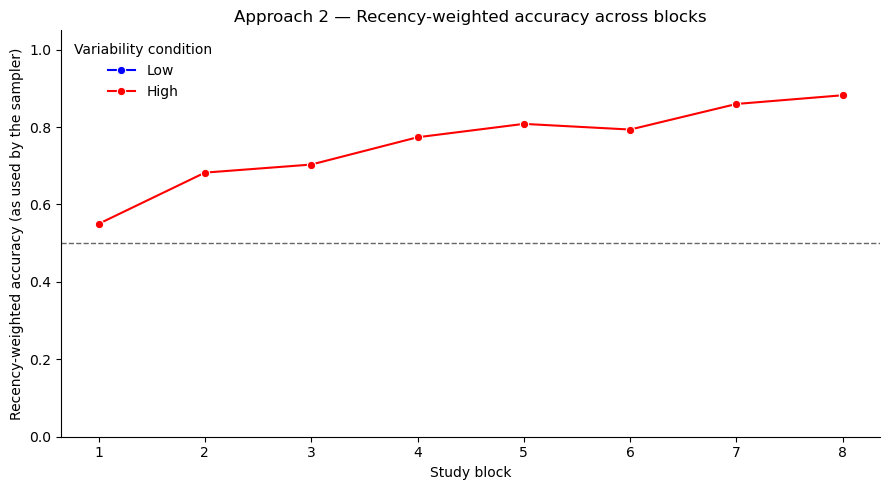

,condition,block,recency_weighted_accuracy,n_items
0,High,1,0.550000,20
1,High,2,0.682353,20
2,High,3,0.703179,20
3,High,4,0.773721,20
4,High,5,0.808295,20
5,High,6,0.793640,20
6,High,7,0.859781,20
7,High,8,0.882288,20


In [33]:

fig, ax = plt.subplots(figsize=(9, 5))
for cond in conditions:
    sub = by_block[by_block['condition'] == cond]
    sns.lineplot(data=sub, x='block', y='recency_weighted_accuracy',
                 marker='o', color=cond_colors[cond], label=cond, ax=ax)

ax.axhline(0.5, color='0.4', ls='--', lw=1)
ax.set_xlabel('Study block')
ax.set_ylabel('Recency-weighted accuracy (as used by the sampler)')
ax.set_ylim(0, 1.05)
ax.set_xticks(sorted(by_block['block'].unique()))
ax.set_title('Approach 2 — Recency-weighted accuracy across blocks')
ax.spines[['top', 'right']].set_visible(False)
leg = ax.legend(frameon=False, title='Variability condition')
plt.tight_layout()
plt.show()

by_block


# Models

In [100]:
# test data set
filtered_data_test = filtered_data.query('phase == "Test"')
filtered_data_test

,trial_type,trial_index,date,time,subject_id,study_id,session_id,condition,cond_assign_source,rt,...,filename,category,sub_category,sub_cat_item,object_type,is_correct,trial_in_exp,object_type_detailed,is_good_subj,train_count
160,categorize-image,486,2026-09-02,15:54:53,65fbb4220141f00a2ed68e4b,6a56c41cf23c1e8f3005e950,6a984649adc914f8ef13c13a,Low,DataPipe,1569.0,...,I_Gabbro_05.png,I,Gabbro,5.0,Novel,False,161,Novel_Both,True,2.0
161,categorize-image,489,2026-09-02,15:54:53,65fbb4220141f00a2ed68e4b,6a56c41cf23c1e8f3005e950,6a984649adc914f8ef13c13a,Low,DataPipe,1230.0,...,I_Rhyolite_14.png,I,Rhyolite,14.0,Novel,True,162,Novel_Both,True,0.0
162,categorize-image,492,2026-09-02,15:54:53,65fbb4220141f00a2ed68e4b,6a56c41cf23c1e8f3005e950,6a984649adc914f8ef13c13a,Low,DataPipe,1059.0,...,I_Pumice_03.png,I,Pumice,3.0,Novel,True,163,Novel,True,0.0
163,categorize-image,495,2026-09-02,15:54:53,65fbb4220141f00a2ed68e4b,6a56c41cf23c1e8f3005e950,6a984649adc914f8ef13c13a,Low,DataPipe,846.0,...,S_Sandstone_05.png,S,Sandstone,5.0,Novel,True,164,Novel_Both,True,0.0
164,categorize-image,498,2026-09-02,15:54:53,65fbb4220141f00a2ed68e4b,6a56c41cf23c1e8f3005e950,6a984649adc914f8ef13c13a,Low,DataPipe,951.0,...,I_Obsidian_06.png,I,Obsidian,6.0,Novel,False,165,Novel_Both,True,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72955,categorize-image,1431,2026-09-15,16:59:46,94831,random_swvrpqf7,random_7oaazd59,Low,DataPipe,546.0,...,S_Micrite_12.png,S,Micrite,12.0,Novel,True,476,Novel_Both,True,3.0
72956,categorize-image,1434,2026-09-15,16:59:46,94831,random_swvrpqf7,random_7oaazd59,Low,DataPipe,656.0,...,S_Conglomerate_09.png,S,Conglomerate,9.0,Novel,False,477,Novel_Both,True,0.0
72957,categorize-image,1437,2026-09-15,16:59:46,94831,random_swvrpqf7,random_7oaazd59,Low,DataPipe,720.0,...,S_Chert_14.png,S,Chert,14.0,Novel,True,478,Novel_Both,True,2.0
72958,categorize-image,1440,2026-09-15,16:59:46,94831,random_swvrpqf7,random_7oaazd59,Low,DataPipe,968.0,...,I_Rhyolite_14.png,I,Rhyolite,14.0,Novel,True,479,Novel_Both,True,0.0


In [101]:
print("Test phase:")
print(f"N unique items in High cond: {data_set.query(' phase == "Test" and condition == "High" ').image_id.nunique()}")
print(f"N unique items in Low cond: {data_set.query(' phase == "Test" and condition == "Low" ').image_id.nunique()}")

Test phase:
N unique items in High cond: 320
N unique items in Low cond: 320


In [102]:
print("Study phase:")
print(f"N unique items in High cond: {data_set.query(' phase == "Study" and condition == "High" ').image_id.nunique()}")
print(f"N unique items in Low cond: {data_set.query(' phase == "Study" and condition == "Low" ').image_id.nunique()}")

Study phase:
N unique items in High cond: 20
N unique items in Low cond: 20


In [103]:
# Read MDS solution
mds_solution = pd.read_csv('https://raw.githubusercontent.com/DaniilAzarov123/Rocks_Database/main/info/Rocks480_MDS8_solution.csv') # pd.read_csv('data_processed/MDS8_solution.csv')
mds_coords = mds_solution.set_index('image_id').iloc[:, :8]
mds_coords

,dim1,dim2,dim3,dim4,dim5,dim6,dim7,dim8
image_id,,,,,,,,
1,-2.757,-1.594,1.052,0.768,1.343,1.711,1.795,0.809
2,2.001,-0.754,1.405,-1.382,-1.384,0.976,-0.067,1.972
3,0.261,-0.508,-2.962,-0.608,0.009,-0.191,2.720,-1.224
4,0.382,-0.027,-0.148,-1.899,-1.948,1.862,0.968,0.986
5,0.288,2.013,-1.102,-1.285,0.344,-0.009,2.696,-0.174
...,...,...,...,...,...,...,...,...
476,0.749,-3.021,-1.908,-1.689,-0.493,4.441,-0.122,1.618
477,-0.054,-2.743,-1.435,-2.903,0.315,3.161,1.833,1.288
478,0.007,-2.077,-4.012,-1.633,-0.366,2.558,4.210,-0.060


In [104]:
# Test and Study items from each category

# ========== Study-Low ==========
study_items_low_I =np.sort(data_set.loc[((data_set['phase'] == 'Study') &
                                         (data_set['condition'] == 'Low') &
                                         (data_set['category'] == 'I')), 
                                        'image_id'].unique())
study_items_low_S =np.sort(data_set.loc[((data_set['phase'] == 'Study') &
                                         (data_set['condition'] == 'Low') &
                                         (data_set['category'] == 'S')), 
                                        'image_id'].unique())

# ========== Study-High ==========
study_items_high_I =np.sort(data_set.loc[((data_set['phase'] == 'Study') &
                                         (data_set['condition'] == 'High') &
                                         (data_set['category'] == 'I')), 
                                        'image_id'].unique())
study_items_high_S =np.sort(data_set.loc[((data_set['phase'] == 'Study') &
                                         (data_set['condition'] == 'High') &
                                         (data_set['category'] == 'S')), 
                                        'image_id'].unique())

# ========== All test items ==========
all_test_items = np.sort(filtered_data_test['image_id'].unique())

In [105]:
# Calculate Euclidean distances between test items and study items in MDS space
study_items_dict = {
    'Low': {
        'I': study_items_low_I,
        'S': study_items_low_S,
    },
    'High': {
        'I': study_items_high_I,
        'S': study_items_high_S,
    }
}

conditions = ['Low', 'High']
categories = ['I', 'S']
distances_dict = {}

for cond in conditions:
    distances_dict[cond] = {}
    for cat in categories:
        study_items = study_items_dict[cond][cat]
        dist_mat = np.linalg.norm(
            mds_coords.loc[all_test_items].values[:, None] - 
            mds_coords.loc[study_items].values[None, :],
            axis=2)
        distances_dict[cond][cat] = pd.DataFrame(dist_mat, index=all_test_items, columns=study_items)

## GCM

In [106]:
# ── Build image_id → sub_category/category lookup ─────────────────────────
# This is from Exp 1 (may not need here, but keeping it for now)
image_info = (data_set[['image_id', 'sub_category', 'category']]
              .drop_duplicates()
              .set_index('image_id'))

In [107]:
# GCM
def GCM(parameters,
        data_test      = filtered_data_test,
        distances_dict = distances_dict,
        image_info     = image_info):

    params = [float(p) for p in parameters]

    if len(params) == 1:
        c_within, c_between, k = params[0], params[0], 0
    elif len(params) == 2:
        c_within, c_between, k = params[0], params[1], 0
    elif len(params) == 3:
        c_within, c_between, k = params
    else:
        raise ValueError(f'Expected 1, 2, or 3 parameters, got {len(params)}')

    conditions = data_test.condition.unique().tolist()
    categories = ['I', 'S']

    # Step 1: Compute evidence for every test image and category
    evidence_dict = {}

    for cond in conditions:
        evidence_dict[cond] = {}

        for cat in categories:
            dist_mat = distances_dict[cond][cat]

            test_ids = dist_mat.index
            study_ids = dist_mat.columns

            # Sub-category lookup
            test_subcats = image_info.loc[
                test_ids, 'sub_category'
            ].to_numpy()

            study_subcats = image_info.loc[
                study_ids, 'sub_category'
            ].to_numpy()

            # Within-subcategory mask
            within_mask = (
                test_subcats[:, None] == study_subcats[None, :]
            )

            # Apply c_within or c_between
            sim_mat = np.where(
                within_mask,
                np.exp(-c_within * dist_mat.to_numpy()),
                np.exp(-c_between * dist_mat.to_numpy())
            )

            # Sum similarity to obtain category evidence
            evidence_dict[cond][cat] = sim_mat.sum(axis=1)

    # Step 2: Compute P(Category | image)
    records = []

    for cond in conditions:

        # Total evidence across the TWO categories
        total_evidence = sum(
            evidence_dict[cond][cat]
            for cat in categories
        )

        # Same test images for both categories
        test_ids = distances_dict[cond][categories[0]].index

        for cat in categories:

            p_cat = (
                evidence_dict[cond][cat] + k
            ) / (
                total_evidence + len(categories) * k
            )

            for image_id, p in zip(test_ids, p_cat):
                records.append({
                    'condition': cond,
                    'image_id': image_id,
                    'category': cat,
                    'p_correct': p
                })

    predictions_df = pd.DataFrame(records)

    # Convert I/S probabilities to wide format
    predictions_df_wide = predictions_df.pivot(
        index=['condition', 'image_id'],
        columns='category',
        values='p_correct'
    ).reset_index()

    # Predicted category = category with highest probability
    predictions_df_wide['predicted_cat'] = (
        predictions_df_wide[categories]
        .idxmax(axis=1)
    )

    # Rename probability columns
    predictions_df_wide = predictions_df_wide.rename(columns={
        'I': 'cat_I_pred_prob',
        'S': 'cat_S_pred_prob'
    })

    # Merge predictions back with original test data
    result_df = (
        data_test
        .merge(
            predictions_df_wide,
            on=['condition', 'image_id'],
            how='left'
        )
        .loc[:, [
            'subject_id',
            'condition',
            'image_id',
            'cat_I_pred_prob',
            'cat_S_pred_prob',
            'predicted_cat'
        ]]
    )

    return result_df['predicted_cat'], result_df

In [108]:
# GCM with c and k
# use it for single c and k 
def GCM_ck(parameters, 
           data_test=filtered_data_test,
           distances_dict=distances_dict, 
           image_info=image_info):
    c, k = float(parameters[0]), float(parameters[1])
    return GCM([c, c, k], data_test, distances_dict, image_info)

# Optimization

## c_w, c_b, k

In [109]:
def NLL(parameters,
        model,
        data_test      = filtered_data_test,
        distances_dict = distances_dict,
        image_info     = image_info,
        prob_cat_map   = {'I': 'cat_I_pred_prob',
                          'S': 'cat_S_pred_prob'}):

    _, result_df = model(parameters, data_test, distances_dict, image_info)

    result_df = result_df.merge(
        data_test[['subject_id', 'condition', 'image_id', 'response']],
        on=['subject_id', 'condition', 'image_id'],
        how='left'
    )

    result_df['p_response'] = result_df.apply(
        lambda row: row[prob_cat_map[row['response']]],
        axis=1
    )

    result_df['p_response'] = result_df['p_response'].clip(lower=1e-10)

    return -np.log(result_df['p_response']).sum()

In [110]:
# ── Model fits ────────────────────────────────────────────────────────────
models_fits = {}

In [111]:
# GCM-c: single c
fit = minimize(NLL, 
               x0=[0.1], 
               args=(GCM,),
               method='Nelder-Mead', 
               options={'maxiter': 1000, 'disp': True})

models_fits['GCM_c'] = {'fit': fit, 'per_condition': False}
print(f"GCM_c:     c={fit.x[0]:.3f}, NLL={fit.fun:.3f}")


Optimization terminated successfully.
         Current function value: 27052.956340
         Iterations: 19
         Function evaluations: 38
GCM_c:     c=0.692, NLL=27052.956


In [112]:
# GCM-c per condition
cond_fits = {}
for cond in ['Low', 'High']:
    data_cond           = filtered_data_test[filtered_data_test['condition'] == cond]
    distances_dict_cond = {cond: distances_dict[cond]}
    fit = minimize(NLL, 
                   x0=[0.1], 
                   args=(GCM, data_cond, distances_dict_cond, image_info),
                   method='Nelder-Mead', 
                   options={'maxiter': 1000, 'disp': True})
    cond_fits[cond] = fit
    print(f"GCM_c_per_cond [{cond}]: c={fit.x[0]:.3f}, NLL={fit.fun:.3f}")

models_fits['GCM_c_per_cond'] = {'fit': cond_fits, 'per_condition': True}

Optimization terminated successfully.
         Current function value: 12773.943528
         Iterations: 19
         Function evaluations: 38
GCM_c_per_cond [Low]: c=0.822, NLL=12773.944
Optimization terminated successfully.
         Current function value: 14107.727991
         Iterations: 18
         Function evaluations: 36
GCM_c_per_cond [High]: c=0.591, NLL=14107.728


In [113]:
# GCM-ck: single c + k
fit = minimize(NLL, 
               x0=[0.1, 0.1], 
               args=(GCM_ck,),
               method='Nelder-Mead', 
               options={'maxiter': 1000, 'disp': True})

models_fits['GCM_ck'] = {'fit': fit, 'per_condition': False}
print(f"GCM_ck:    c={fit.x[0]:.3f}, k={fit.x[1]:.3f}, NLL={fit.fun:.3f}")

Optimization terminated successfully.
         Current function value: 27105.009464
         Iterations: 58
         Function evaluations: 112
GCM_ck:    c=0.587, k=-0.061, NLL=27105.009


In [114]:
# GCM-ck per condition
cond_fits = {}
for cond in ['Low', 'High']:
    data_cond           = filtered_data_test[filtered_data_test['condition'] == cond]
    distances_dict_cond = {cond: distances_dict[cond]}
    fit = minimize(NLL, 
                   x0=[0.1, 0.1], 
                   args=(GCM_ck, data_cond, distances_dict_cond, image_info),
                   method='Nelder-Mead', 
                   options={'maxiter': 1000, 'disp': True})
    cond_fits[cond] = fit
    print(f"GCM_ck_per_cond [{cond}]: c={fit.x[0]:.3f}, k={fit.x[1]:.3f}, NLL={fit.fun:.3f}")

models_fits['GCM_ck_per_cond'] = {'fit': cond_fits, 'per_condition': True}

Optimization terminated successfully.
         Current function value: 12771.451555
         Iterations: 84
         Function evaluations: 159
GCM_ck_per_cond [Low]: c=0.799, k=-0.003, NLL=12771.452
Optimization terminated successfully.
         Current function value: 14088.420360
         Iterations: 51
         Function evaluations: 97
GCM_ck_per_cond [High]: c=0.502, k=-0.117, NLL=14088.420


In [115]:
# GCM-cwb: c_within + c_between, no k — x0 has 2 elements now
fit = minimize(NLL, x0=[0.1, 0.1], args=(GCM,),
               method='Nelder-Mead', options={'maxiter': 1000, 'disp': True})
models_fits['GCM_cwb'] = {'fit': fit, 'per_condition': False, 'model_fn': GCM}
print(f"GCM_cwb: c_w={fit.x[0]:.3f}, c_b={fit.x[1]:.3f}, NLL={fit.fun:.3f}")

Optimization terminated successfully.
         Current function value: 26941.025219
         Iterations: 51
         Function evaluations: 99
GCM_cwb: c_w=0.448, c_b=0.633, NLL=26941.025


In [116]:
# GCM-cwb per condition
cond_fits = {}
for cond in ['Low', 'High']:
    data_cond           = filtered_data_test[filtered_data_test['condition'] == cond]
    distances_dict_cond = {cond: distances_dict[cond]}
    fit = minimize(NLL, x0=[0.1, 0.1],
                   args=(GCM, data_cond, distances_dict_cond, image_info),
                   method='Nelder-Mead', options={'maxiter': 1000, 'disp': True})
    cond_fits[cond] = fit
    print(f"GCM_cwb_per_cond [{cond}]: c_w={fit.x[0]:.3f}, c_b={fit.x[1]:.3f}, NLL={fit.fun:.3f}")
models_fits['GCM_cwb_per_cond'] = {'fit': cond_fits, 'per_condition': True, 'model_fn': GCM}

Optimization terminated successfully.
         Current function value: 12732.792081
         Iterations: 53
         Function evaluations: 101
GCM_cwb_per_cond [Low]: c_w=0.561, c_b=0.764, NLL=12732.792
Optimization terminated successfully.
         Current function value: 14020.856592
         Iterations: 51
         Function evaluations: 97
GCM_cwb_per_cond [High]: c_w=0.329, c_b=0.528, NLL=14020.857


In [117]:
# GCM-cwb-k: c_within + c_between + k
fit = minimize(NLL, 
               x0=[0.1, 0.1, 0.1], 
               args=(GCM,),
               method='Nelder-Mead', 
               options={'maxiter': 1000, 'disp': True})
models_fits['GCM_cwb_k'] = {'fit': fit, 'per_condition': False, 'model_fn': GCM}
print(f"GCM_cwb_k: c_w={fit.x[0]:.3f}, c_b={fit.x[1]:.3f}, k={fit.x[2]:.3f}, NLL={fit.fun:.3f}")

Optimization terminated successfully.
         Current function value: 27009.700128
         Iterations: 123
         Function evaluations: 221
GCM_cwb_k: c_w=0.380, c_b=0.537, k=-0.087, NLL=27009.700


In [118]:
# GCM-cwb-k per condition
cond_fits = {}
for cond in ['Low', 'High']:
    data_cond           = filtered_data_test[filtered_data_test['condition'] == cond]
    distances_dict_cond = {cond: distances_dict[cond]}
    fit = minimize(NLL, 
                   x0=[0.1, 0.1, 0.1],
                   args=(GCM, data_cond, distances_dict_cond, image_info),
                   method='Nelder-Mead', 
                   options={'maxiter': 1000, 'disp': True})
    cond_fits[cond] = fit
    print(f"GCM_cwb_k_per_cond [{cond}]: c_w={fit.x[0]:.3f}, c_b={fit.x[1]:.3f}, k={fit.x[2]:.3f}, NLL={fit.fun:.3f}")
models_fits['GCM_cwb_k_per_cond'] = {'fit': cond_fits, 'per_condition': True, 'model_fn': GCM}

Optimization terminated successfully.
         Current function value: 12729.963903
         Iterations: 214
         Function evaluations: 376
GCM_cwb_k_per_cond [Low]: c_w=0.536, c_b=0.737, k=-0.005, NLL=12729.964
Optimization terminated successfully.
         Current function value: 14018.312327
         Iterations: 97
         Function evaluations: 170
GCM_cwb_k_per_cond [High]: c_w=0.314, c_b=0.493, k=-0.066, NLL=14018.312


# Model Preds

In [119]:
# Store model_fn alongside each entry so get_plot_df knows which function to call
models_fits['GCM_c'              ]['model_fn'] = GCM
models_fits['GCM_c_per_cond'     ]['model_fn'] = GCM
models_fits['GCM_ck'             ]['model_fn'] = GCM_ck
models_fits['GCM_ck_per_cond'    ]['model_fn'] = GCM_ck
models_fits['GCM_cwb'            ]['model_fn'] = GCM
models_fits['GCM_cwb_per_cond'   ]['model_fn'] = GCM
models_fits['GCM_cwb_k'          ]['model_fn'] = GCM
models_fits['GCM_cwb_k_per_cond' ]['model_fn'] = GCM

In [120]:
# Model predictions
def get_predictions(model_name, models_fits, filtered_data_test,
                    distances_dict, image_info):
    
    entry    = models_fits[model_name]
    model_fn = entry['model_fn']

    if not entry['per_condition']:
        _, result_df = model_fn(entry['fit'].x)
    else:
        dfs = []
        for cond in ['Low', 'High']:
            fit                 = entry['fit'][cond]
            data_cond           = filtered_data_test[filtered_data_test['condition'] == cond]
            distances_dict_cond = {cond: distances_dict[cond]}
            _, res              = model_fn(fit.x, data_test=data_cond,
                                           distances_dict=distances_dict_cond,
                                           image_info=image_info)
            dfs.append(res)
        result_df = pd.concat(dfs, ignore_index=True)

    result_df = result_df.merge(
        filtered_data_test[['subject_id', 'condition', 'image_id',
                             'category', 'response', 'object_type_detailed']],
        on=['subject_id', 'condition', 'image_id'], how='left'
    )
    return result_df

In [121]:
# Aggregated predictions
def get_agg_df(result_df):

    agg_records = []
    for (cond, image_id, true_cat, item_type), grp in result_df.groupby(
            ['condition', 'image_id', 'category', 'object_type_detailed']):
        n_total = len(grp)
        for resp_cat in ['I', 'S']:
            pred_prob = grp[f'cat_{resp_cat}_pred_prob'].mean()
            obs_prop  = (grp['response'] == resp_cat).sum() / n_total
            agg_records.append({
                'condition': cond,
                'image_id':  image_id,
                'true_cat':  true_cat,
                'item_type': item_type,
                'resp_cat':  resp_cat,
                'pred_prob': pred_prob,
                'obs_prop':  obs_prop,
            })
    return pd.DataFrame(agg_records)


In [122]:
# Getting all predictions together
all_predictions = {}

for model_name in models_fits.keys():
    print(f'Getting predictions for {model_name}...')
    result_df = get_predictions(model_name, models_fits, filtered_data_test,
                                distances_dict, image_info)
    agg_df    = get_agg_df(result_df)
    all_predictions[model_name] = {
        'result_df': result_df,
        'agg_df':    agg_df,
    }

print('Done!')

Getting predictions for GCM_c...
Getting predictions for GCM_c_per_cond...
Getting predictions for GCM_ck...
Getting predictions for GCM_ck_per_cond...
Getting predictions for GCM_cwb...
Getting predictions for GCM_cwb_per_cond...
Getting predictions for GCM_cwb_k...
Getting predictions for GCM_cwb_k_per_cond...
Done!


# Visualizaton

## Bar plot

In [123]:
def get_model_plot_df(model_name, all_predictions, filtered_data_test):
    result_df = all_predictions[model_name]['result_df'].copy()
    
    # only is_correct is missing from result_df
    result_df = result_df.merge(
        filtered_data_test[['subject_id', 'condition', 'image_id', 'is_correct']],
        on=['subject_id', 'condition', 'image_id'], how='left'
    )
    result_df['GCM_true_cat_pred_prob'] = result_df.apply(
        lambda row: row[f"cat_{row['category']}_pred_prob"], axis=1
    )
    plot_df = result_df.groupby(['condition', 'object_type_detailed']).agg(
        Human_Acc_Mean=('is_correct',             'mean'),
        GCM_Acc_Mean  =('GCM_true_cat_pred_prob', 'mean'),
    ).reset_index()
    plot_df = plot_df.query("object_type_detailed != 'Novel'")
    return plot_df

In [124]:
def plot_agg_obs_vs_pred(all_predictions, filtered_data_test, model_styles,
                     title='Aggregated Observed Data vs Model Predictions',
                     save_path=None):

    item_types  = ['Study', 'Novel_Both']
    item_labels = ['Study Items', 'Novel Items\n(in Both Conditions)']
    conditions  = ['Low', 'High']
    colors_cond = {'Low': 'blue', 'High': 'red'}
    dodge       = {'Low': -0.15, 'High': 0.15}
    x_base      = np.arange(len(item_types))

    fig, ax = plt.subplots(1, 1, figsize=(8, 5))

    for condition in conditions:
        color = colors_cond[condition]
        x     = x_base + dodge[condition]

        # Human bars — take from first model, data is the same
        first_model = list(model_styles.keys())[0]
        plot_df     = get_model_plot_df(first_model, all_predictions, filtered_data_test)
        human_means = []
        for item_type in item_types:
            subset = plot_df[(plot_df['condition']            == condition) &
                             (plot_df['object_type_detailed'] == item_type)]
            human_means.append(subset['Human_Acc_Mean'].values[0] if not subset.empty else np.nan)
        ax.bar(x, human_means, width=0.28, color=color, alpha=0.6)

        k_shift = 0.05  # within-condition horizontal offset
        # Model markers
        for model_name, style in model_styles.items():
            model_offset = k_shift if style.get('shift_right', False) else -k_shift
            x_model = x + model_offset

            plot_df   = get_model_plot_df(model_name, all_predictions, filtered_data_test)
            gcm_means = []
            for item_type in item_types:
                subset = plot_df[(plot_df['condition']            == condition) &
                                 (plot_df['object_type_detailed'] == item_type)]
                gcm_means.append(subset['GCM_Acc_Mean'].values[0] if not subset.empty else np.nan)
            ax.plot(x_model, gcm_means, style['marker'], color=color, alpha=0.9,
                    markersize=9, markeredgecolor='black', markeredgewidth=0.8)

    ax.axhline(y=1/2, color='gray', linestyle='dashed', linewidth=1.5)
    ax.set_xticks(x_base)
    ax.set_xticklabels(item_labels, fontsize=11)
    ax.set_ylim(0, 1)
    ax.set_yticks(np.arange(0, 1.1, 0.1))
    ax.set_ylabel('P(correct category)', fontsize=11)
    ax.grid(axis='y', linestyle='--', alpha=0.4)

    legend_handles = [
        mpatches.Patch(color='blue', alpha=0.6, label='Low – Observed'),
        mpatches.Patch(color='red',  alpha=0.6, label='High – Observed'),
        mlines.Line2D([], [], linestyle='None', label=''),
    ] + [
        mlines.Line2D([], [], marker=style['marker'], color='None',
                      markeredgecolor='black', linestyle='None',
                      markersize=9, label=style['label'])
        for style in model_styles.values()
    ] + [
        mlines.Line2D([], [], linestyle='None', label=''),
        mlines.Line2D([], [], color='gray', linestyle='dashed',
                      linewidth=1.5, label='Chance'),
    ]
    ax.legend(handles=legend_handles, fontsize=9,
              bbox_to_anchor=(1.01, 0.5), loc='center left')

    plt.suptitle(title, fontsize=14)
    plt.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'Saved: {save_path}')

    plt.show()

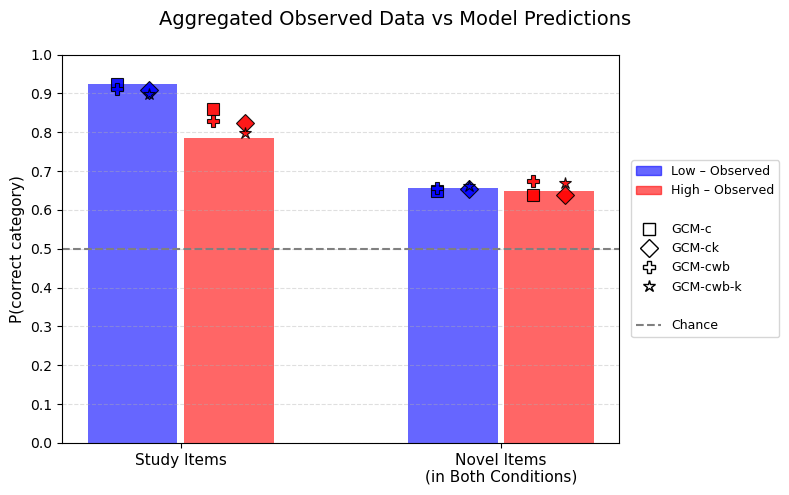

In [125]:
# Parameters are fixed across conditions
model_styles_single = {
    'GCM_c':     {'marker': 's', 'label': 'GCM-c', 'shift_right': False},
    'GCM_ck':    {'marker': 'D', 'label': 'GCM-ck', 'shift_right': True},
    'GCM_cwb':   {'marker': 'P', 'label': 'GCM-cwb', 'shift_right': False},
    'GCM_cwb_k': {'marker': '*', 'label': 'GCM-cwb-k', 'shift_right': True},
}

plot_agg_obs_vs_pred(all_predictions, filtered_data_test, model_styles_single)

## Pred vs Obs

In [126]:
# def plot_calibration(agg_df, model_name, save_path=None,
#                      item_types  = ['Study', 'Novel_Both'],
#                      item_labels = ['Study', 'Novel (Both)']):

#     cond_colors  = {'Low': 'blue', 'High': 'red'}
#     resp_markers = {'I': 'o', 'S': 's'}
#     cat_labels   = {'I': 'Category I', 'S': 'Category S'}

#     n_cols = len(item_types)
#     n_rows = len(resp_markers)
#     fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows),
#                              sharey=True, sharex=True)

#     for row, true_cat in enumerate(['I', 'S']):
#         for col, (item_type, item_label) in enumerate(zip(item_types, item_labels)):
#             ax = axes[row, col]

#             for cond in ['Low', 'High']:
#                 cond_color = cond_colors[cond]
#                 subset = agg_df[(agg_df['condition'] == cond)  &
#                                 (agg_df['true_cat']  == true_cat) &
#                                 (agg_df['item_type'] == item_type)]

#                 for resp_cat in ['I', 'S']:
#                     cell       = subset[subset['resp_cat'] == resp_cat]
#                     marker     = resp_markers[resp_cat]
#                     is_correct = (true_cat == resp_cat)

#                     ax.scatter(
#                         cell['pred_prob'], cell['obs_prop'],
#                         marker     = marker,
#                         color      = cond_color if is_correct else 'none',
#                         edgecolors = cond_color,
#                         linewidths = 1.5,
#                         s          = 50,
#                         alpha      = 0.6,
#                     )

#             ax.plot([0, 1], [0, 1], 'k--', linewidth=1)
#             ax.axhline(1/2, color='gray', linestyle='dotted', linewidth=2, alpha=0.8)
#             ax.axvline(1/2, color='gray', linestyle='dotted', linewidth=2, alpha=0.8)
#             ax.set_xlim(0, 1)
#             ax.set_ylim(0, 1)
#             ax.grid(alpha=0.3)
#             ax.set_title(f'True: {cat_labels[true_cat]} — {item_label}', fontsize=13)

#     for ax in axes[-1, :]:
#         ax.set_xlabel('Model predicted probability', fontsize=13)
#     for ax in axes[:, 0]:
#         ax.set_ylabel('Observed proportion', fontsize=13)

#     # ── Shared legend ──────────────────────────────────────────────────────
#     separator = mlines.Line2D([], [], linestyle='None', label='')

#     legend_elements = []
#     for cond in ['Low', 'High']:
#         cond_color = cond_colors[cond]
#         for resp_cat in ['I', 'S']:
#             marker = resp_markers[resp_cat]
#             legend_elements.append(
#                 mlines.Line2D([], [], marker=marker, color=cond_color,
#                               markeredgecolor=cond_color, linestyle='None',
#                               markersize=13, label=f'{cond} — Resp={resp_cat} ✓')
#             )
#             legend_elements.append(
#                 mlines.Line2D([], [], marker=marker, color='none',
#                               markeredgecolor=cond_color, linestyle='None',
#                               markersize=13, label=f'{cond} — Resp={resp_cat}')
#             )
#         legend_elements.append(separator)

#     legend_elements += [
#         mlines.Line2D([0], [0], color='k',    linestyle='--',     linewidth=2, label='Perfect calibration'),
#         mlines.Line2D([0], [0], color='gray', linestyle='dotted', linewidth=2, label='Chance level'),
#     ]
#     fig.legend(handles=legend_elements, fontsize=13,
#                bbox_to_anchor=(1.01, 0.5), loc='center left', ncol=1)

#     fig.suptitle(f'Model predictions — {model_name}', fontsize=20)
#     plt.tight_layout()
#     plt.subplots_adjust(top=0.93)

#     if save_path is not None:
#         fig.savefig(save_path, dpi=150, bbox_inches='tight')
#         print(f'Saved: {save_path}')

#     plt.show()

In [127]:
def plot_calibration(agg_df, model_name, save_path=None,
                     item_types  = ['Study', 'Novel_Both'],
                     item_labels = ['Study', 'Novel (Both)']):

    cond_colors  = {'Low': 'blue', 'High': 'red'}
    resp_markers = {'I': 'o', 'S': 's'}
    cat_labels   = {'I': 'Category I', 'S': 'Category S'}

    # 4 columns: for each item type, a Correct column then an Incorrect column
    col_specs = []
    for item_type, item_label in zip(item_types, item_labels):
        col_specs.append((item_type, item_label, True))    # correct
        col_specs.append((item_type, item_label, False))   # incorrect

    n_cols = len(col_specs)   # 4
    n_rows = 2                # true cat: I, S
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 6 * n_rows),
                             sharey=True, sharex=True)

    for row, true_cat in enumerate(['I', 'S']):
        for col, (item_type, item_label, want_correct) in enumerate(col_specs):
            ax = axes[row, col]

            target_resp = true_cat if want_correct else ('S' if true_cat == 'I' else 'I')
            marker      = resp_markers[target_resp]

            for cond in ['Low', 'High']:
                cond_color = cond_colors[cond]
                subset = agg_df[(agg_df['condition'] == cond)  &
                                (agg_df['true_cat']  == true_cat) &
                                (agg_df['item_type'] == item_type)]
                cell = subset[subset['resp_cat'] == target_resp]

                ax.scatter(
                    cell['pred_prob'], cell['obs_prop'],
                    marker     = marker,
                    color      = cond_color,
                    edgecolors = cond_color,
                    linewidths = 1.5,
                    s          = 50,
                    alpha      = 0.6,
                )

            ax.plot([0, 1], [0, 1], 'k--', linewidth=1)
            ax.axhline(1/2, color='gray', linestyle='dotted', linewidth=2, alpha=0.8)
            ax.axvline(1/2, color='gray', linestyle='dotted', linewidth=2, alpha=0.8)
            ax.set_xlim(0, 1)
            ax.set_ylim(0, 1)
            ax.grid(alpha=0.3)
            corr_label = 'Correct' if want_correct else 'Incorrect'
            ax.set_title(f'True: {cat_labels[true_cat]} — {item_label}\n({corr_label})',
                         fontsize=12)

    for ax in axes[-1, :]:
        ax.set_xlabel('Model predicted probability', fontsize=13)
    for ax in axes[:, 0]:
        ax.set_ylabel('Observed proportion', fontsize=13)

    # ── Shared legend ──────────────────────────────────────────────────────
    separator = mlines.Line2D([], [], linestyle='None', label='')

    legend_elements = []
    for cond in ['Low', 'High']:
        cond_color = cond_colors[cond]
        for resp_cat in ['I', 'S']:
            legend_elements.append(
                mlines.Line2D([], [], marker=resp_markers[resp_cat], color=cond_color,
                              markeredgecolor=cond_color, linestyle='None',
                              markersize=13, label=f'{cond} — Resp={resp_cat}')
            )
        legend_elements.append(separator)

    legend_elements += [
        mlines.Line2D([0], [0], color='k',    linestyle='--',     linewidth=2, label='Perfect calibration'),
        mlines.Line2D([0], [0], color='gray', linestyle='dotted', linewidth=2, label='Chance level'),
    ]

    fig.suptitle(f'Model predictions — {model_name}', fontsize=20)

    # Reserve right margin for the legend, then anchor it inside that band.
    fig.tight_layout(rect=[0, 0, 0.88, 0.95])
    fig.legend(handles=legend_elements, fontsize=13,
               bbox_to_anchor=(0.89, 0.5), loc='center left', ncol=1)

    if save_path is not None:
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'Saved: {save_path}')

    plt.show()

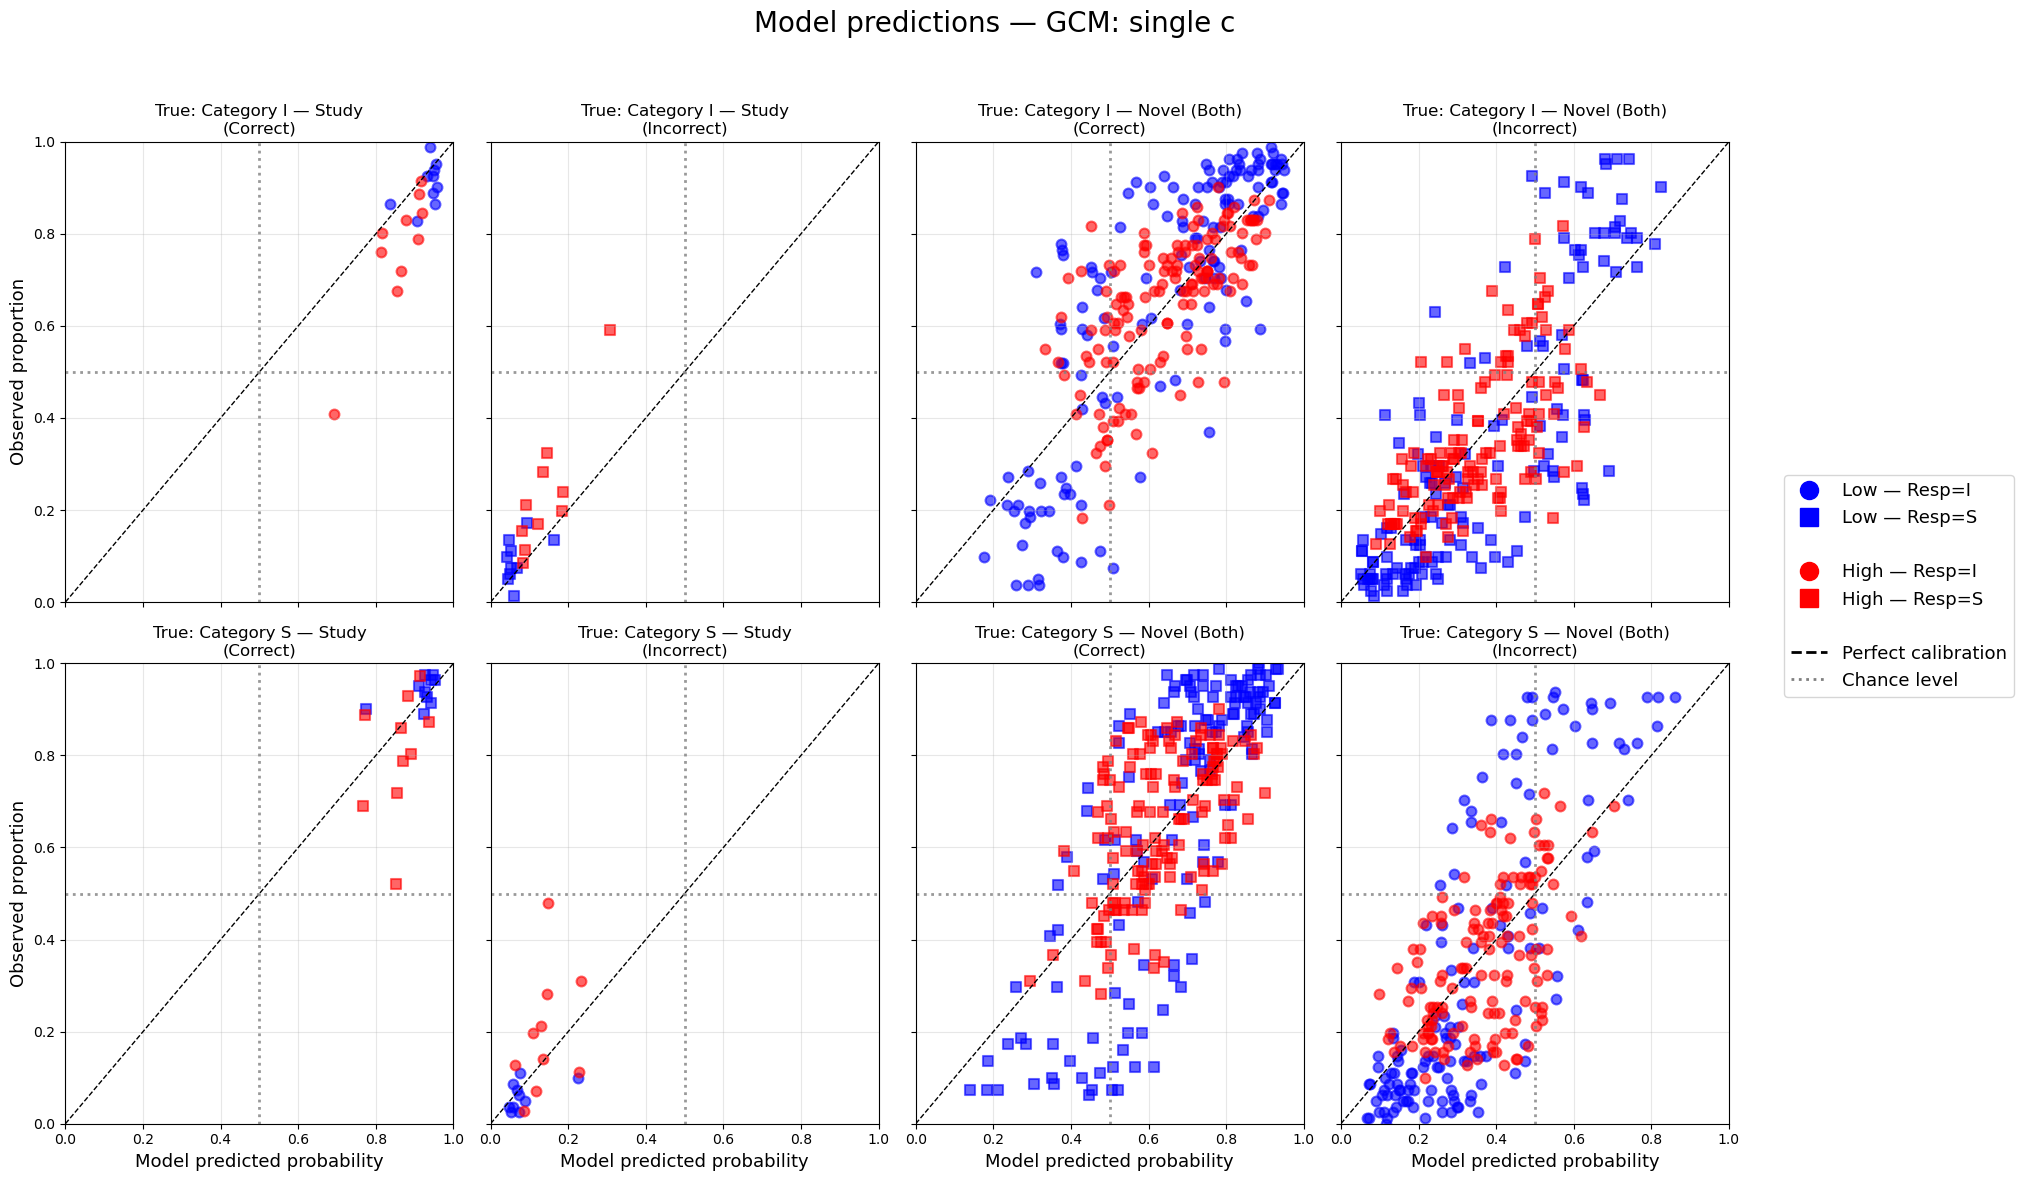

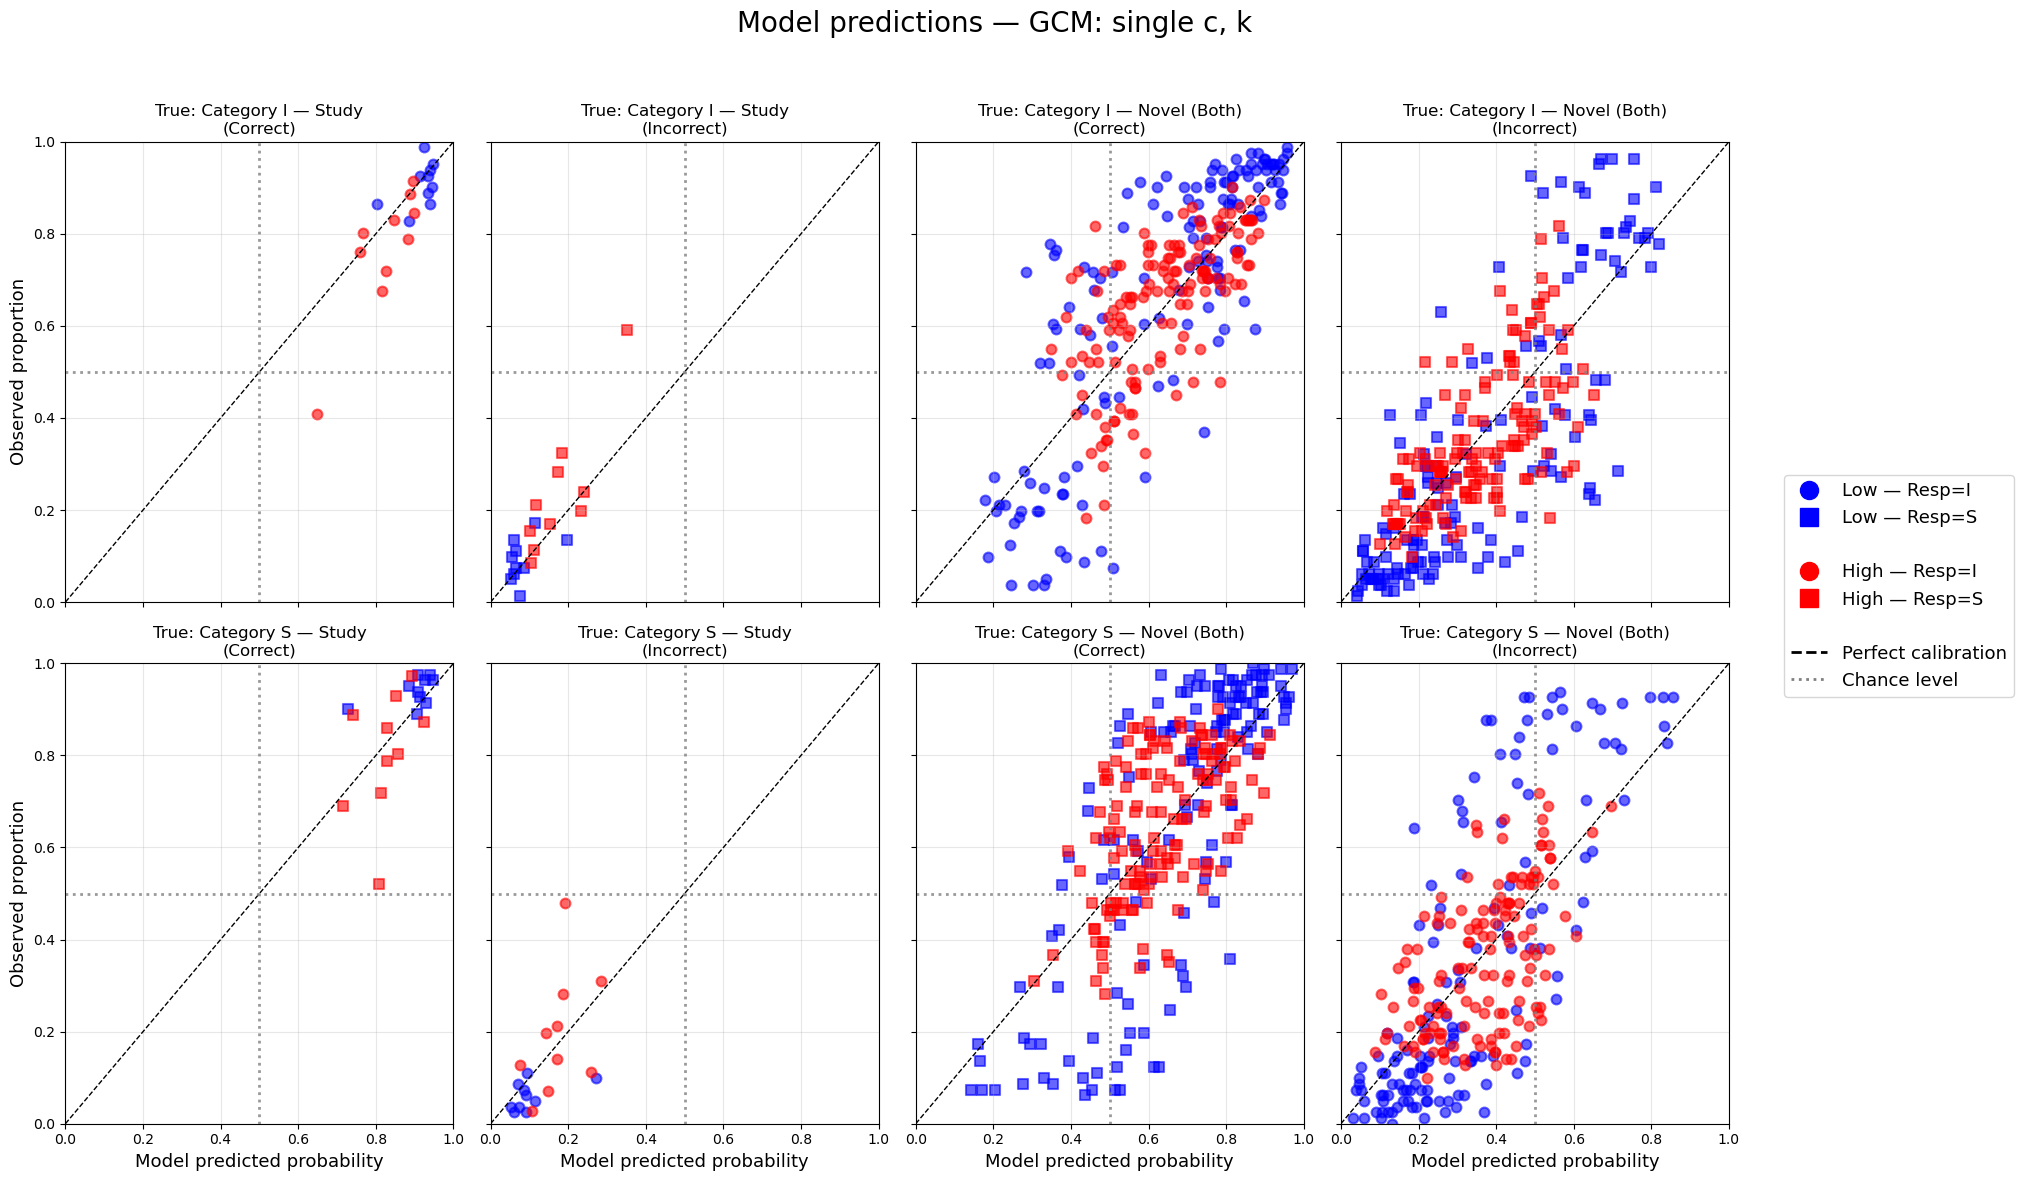

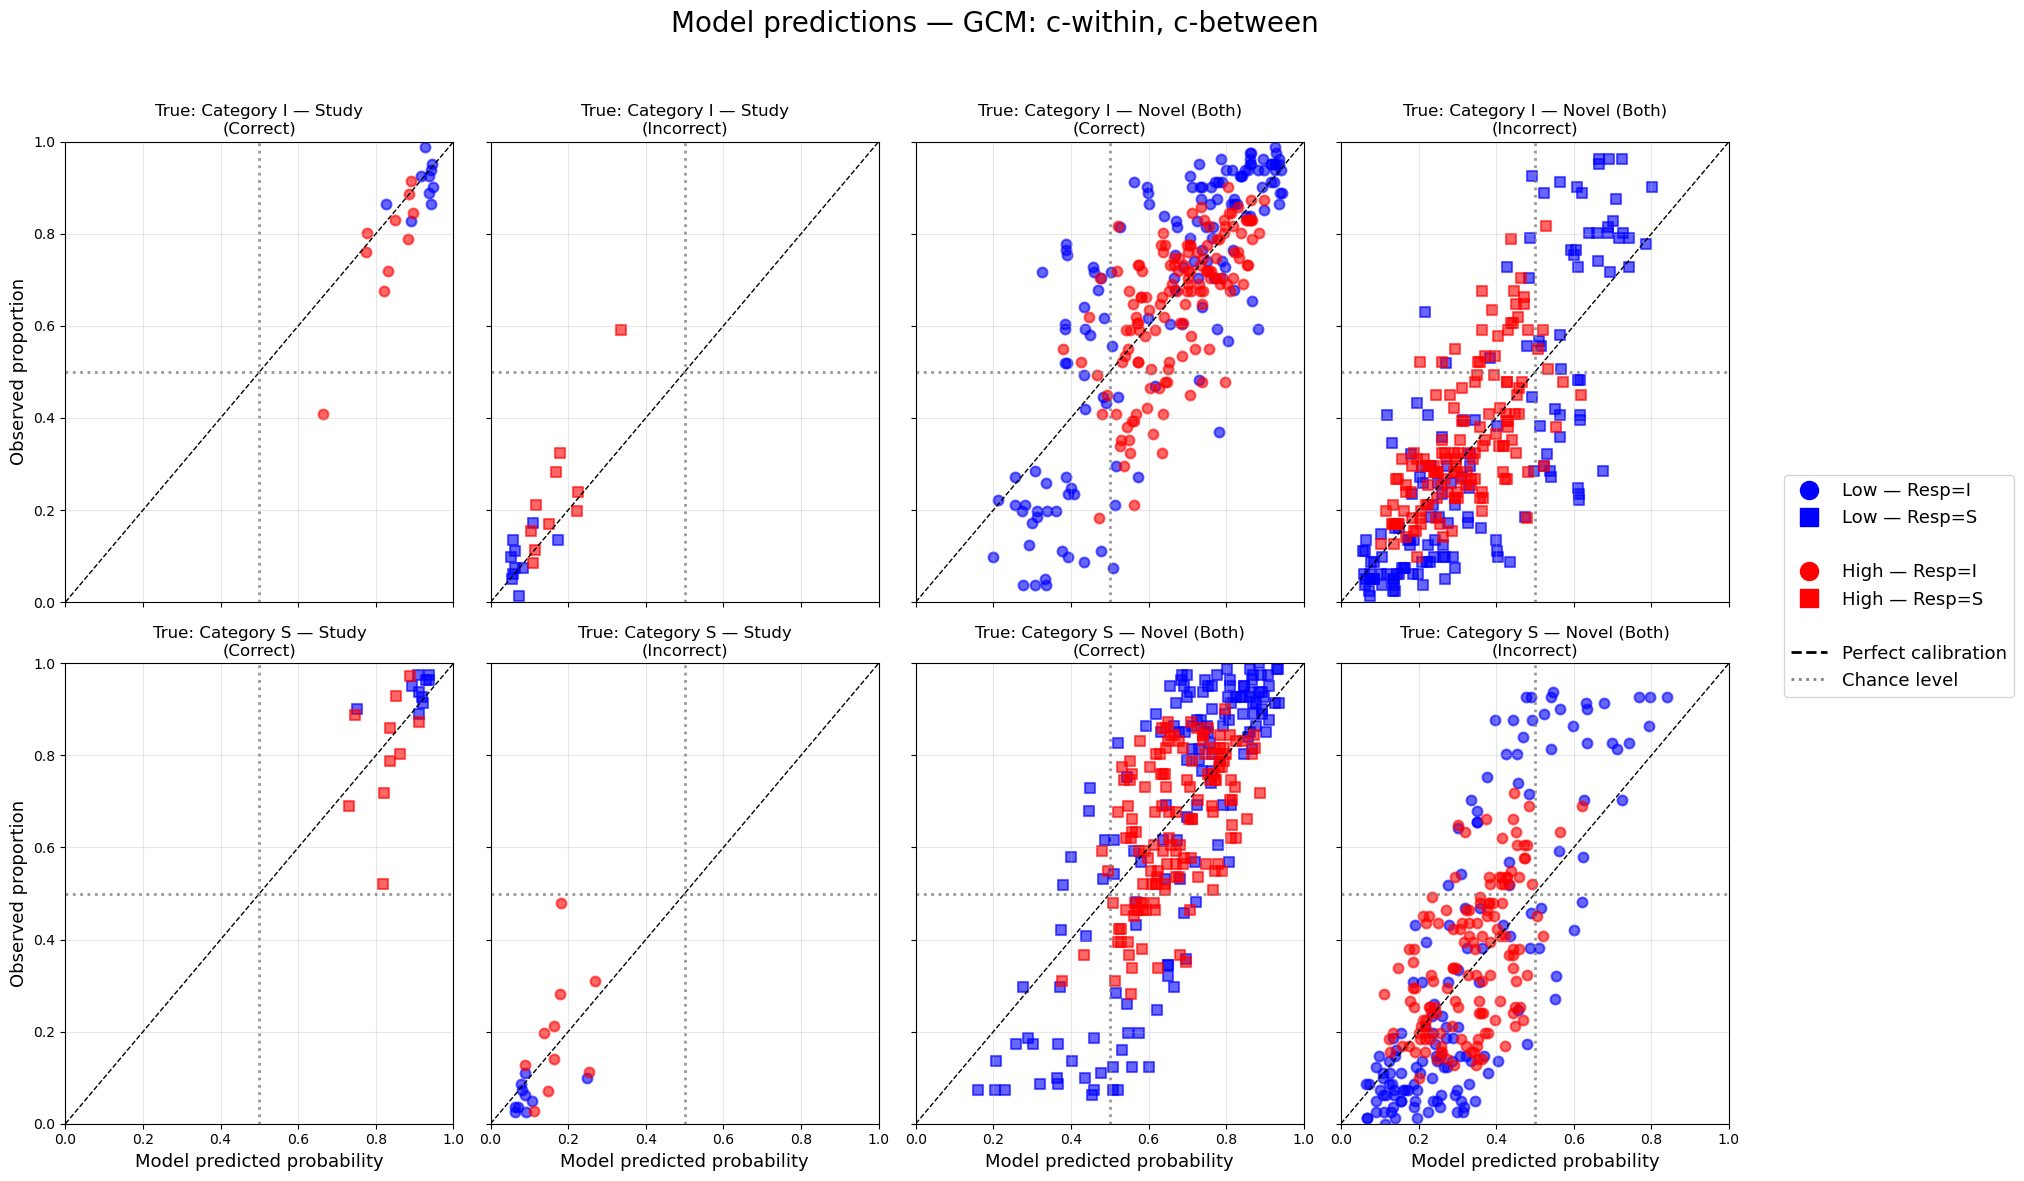

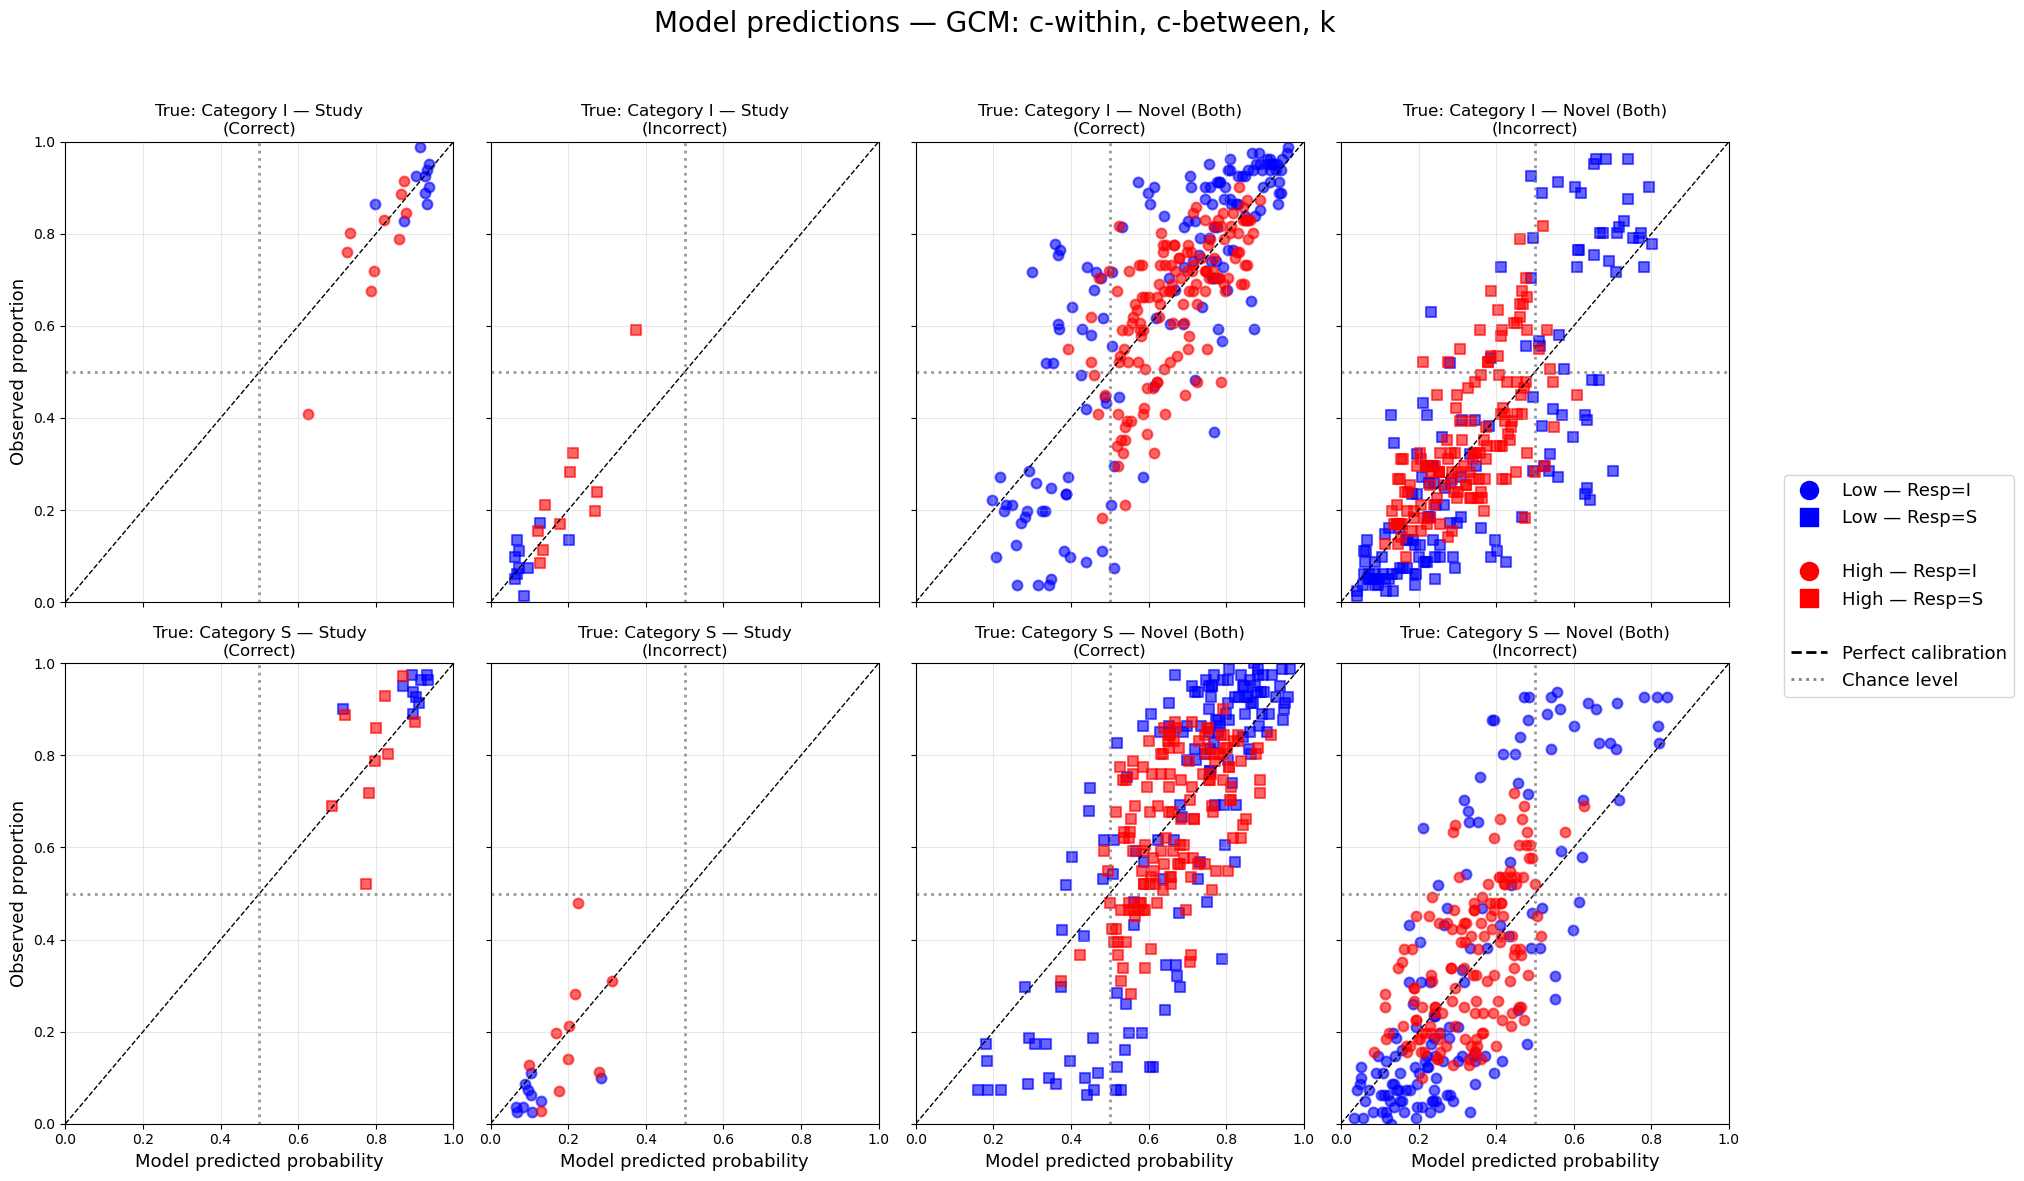

In [128]:
# Model predictions (parameters fixed across conditions)
model_names_singles = {'GCM_c':'GCM: single c',
                       'GCM_ck':'GCM: single c, k',
                       'GCM_cwb':'GCM: c-within, c-between',
                       'GCM_cwb_k':'GCM: c-within, c-between, k'
                       }
for mod, mod_name in model_names_singles.items():
    #save_path = 'plots/model_preds/' + mod + '.png'
    plot_calibration(all_predictions[mod]['agg_df'], mod_name)

## Condition Accuracy on Number of Training Items

In [135]:
# Add sub_category, train_count and P(correct) to a model's per-trial predictions
def prepare_model_df(result_df, filtered_data_test, train_counts):
    keys = ['subject_id', 'condition', 'image_id']

    sub_cat = filtered_data_test[keys + ['sub_category']].drop_duplicates()
    # Safety check: each (subject, condition, image) must map to exactly one sub_category
    assert not sub_cat.duplicated(keys).any(), 'Non-unique sub_category per subject/condition/image'

    n_before = len(result_df)
    df = result_df.merge(sub_cat, on=keys, how='left')
    assert len(df) == n_before, 'Merge changed the number of rows'

    df = add_train_counts(df, train_counts)

    # P(correct) = predicted probability of the true category
    assert set(df['category'].dropna().unique()) <= {'I', 'S'}, 'Unexpected category labels'
    df['pred_correct'] = np.where(df['category'] == 'I',
                                  df['cat_I_pred_prob'],
                                  df['cat_S_pred_prob'])
    return df

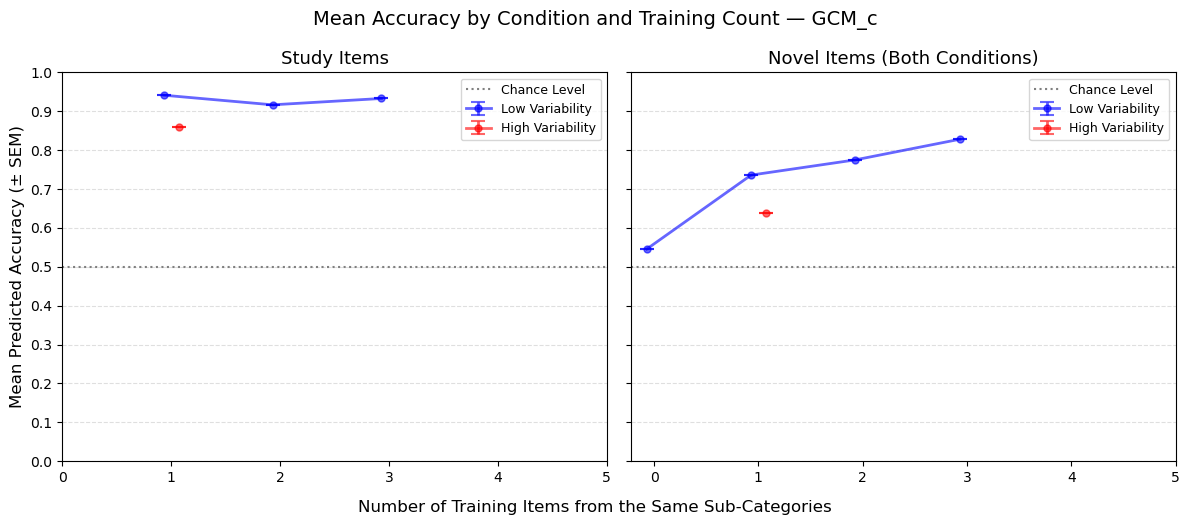

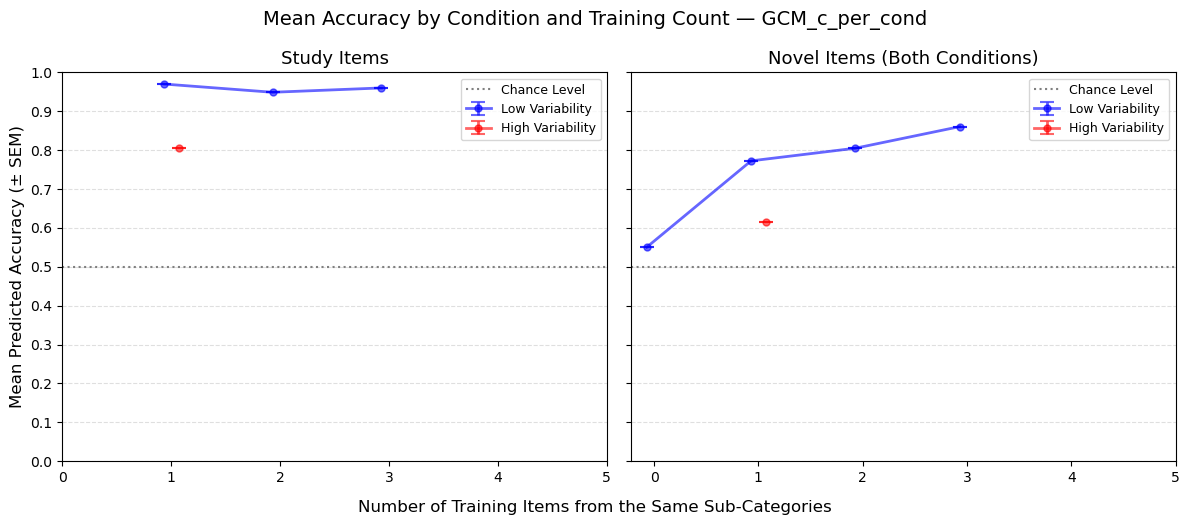

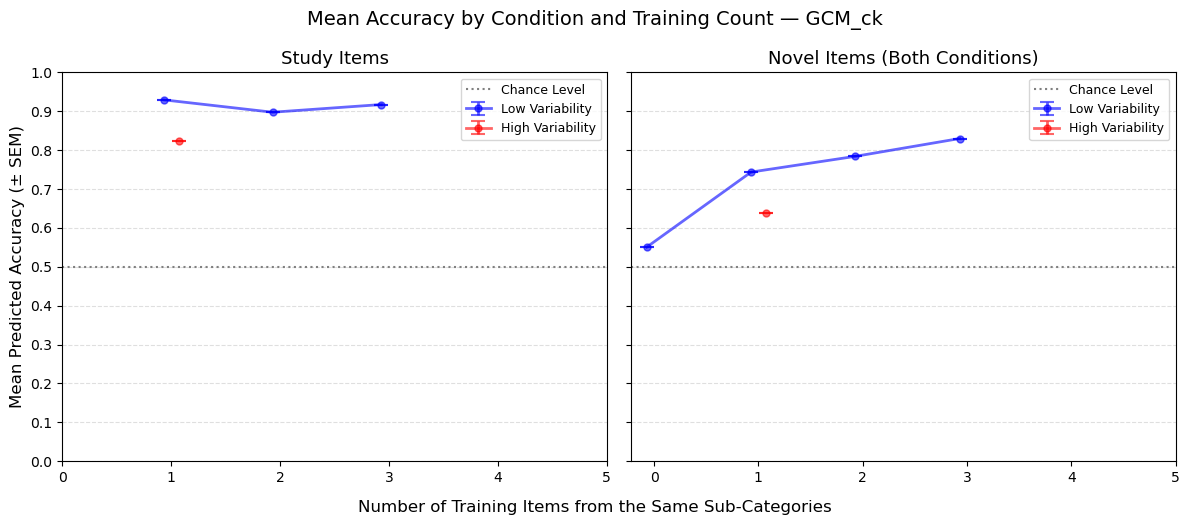

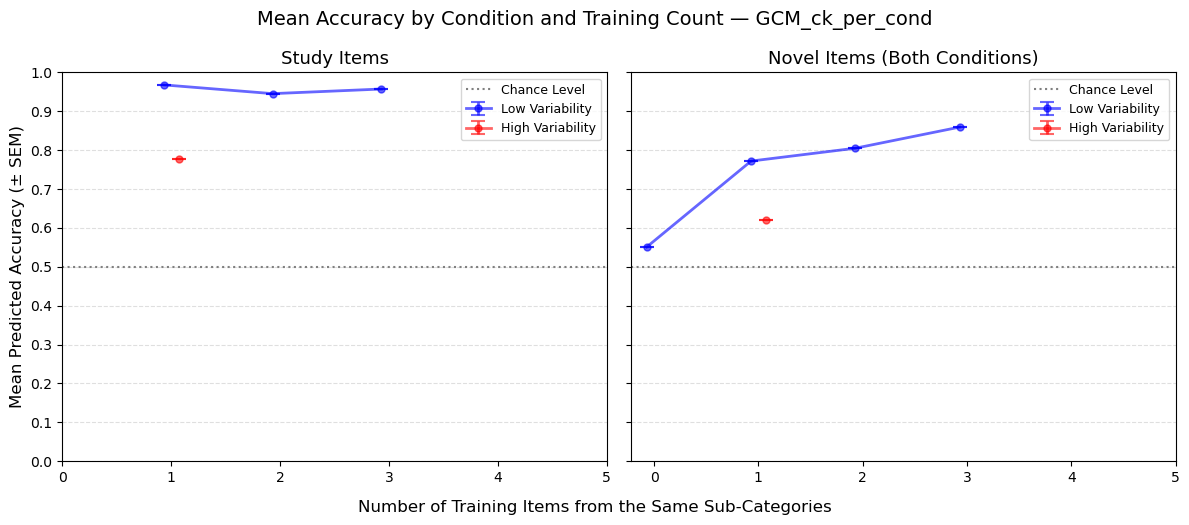

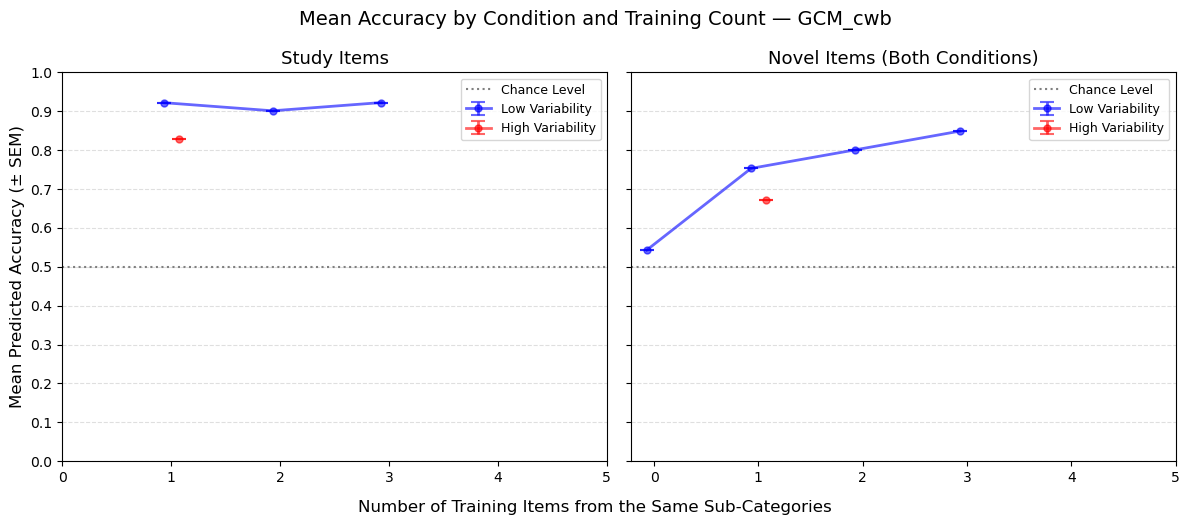

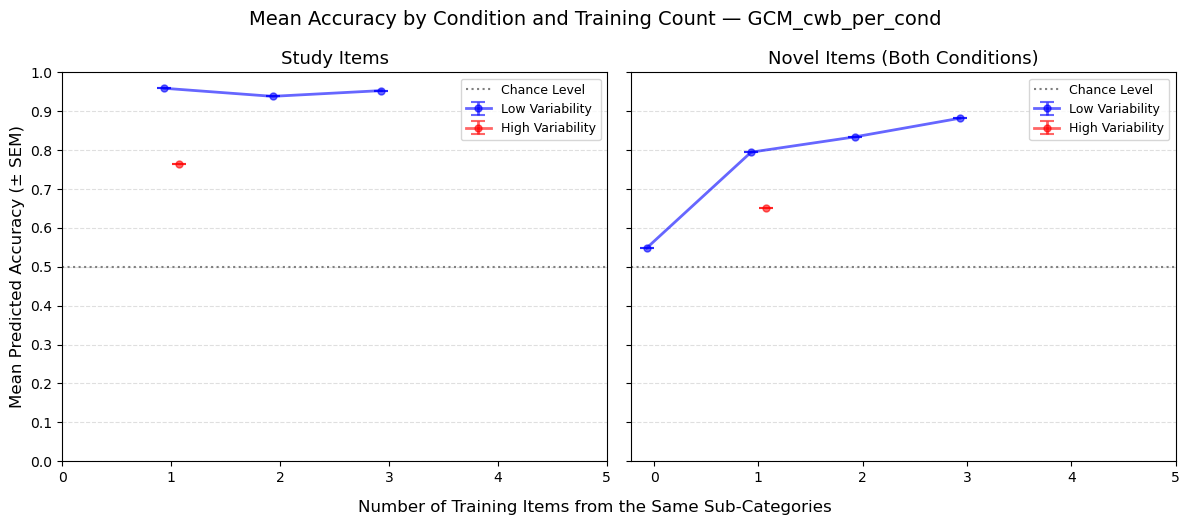

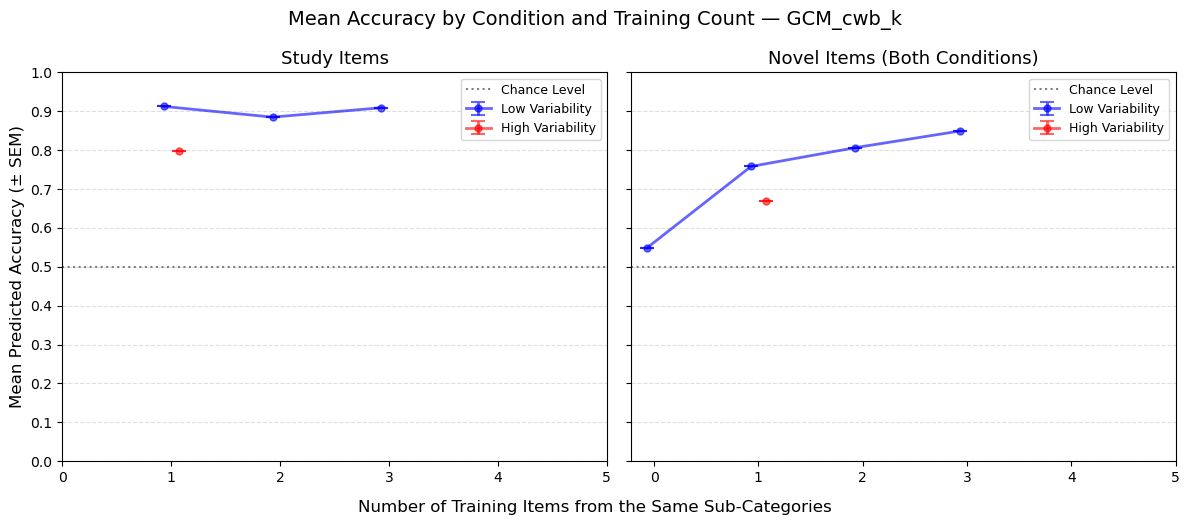

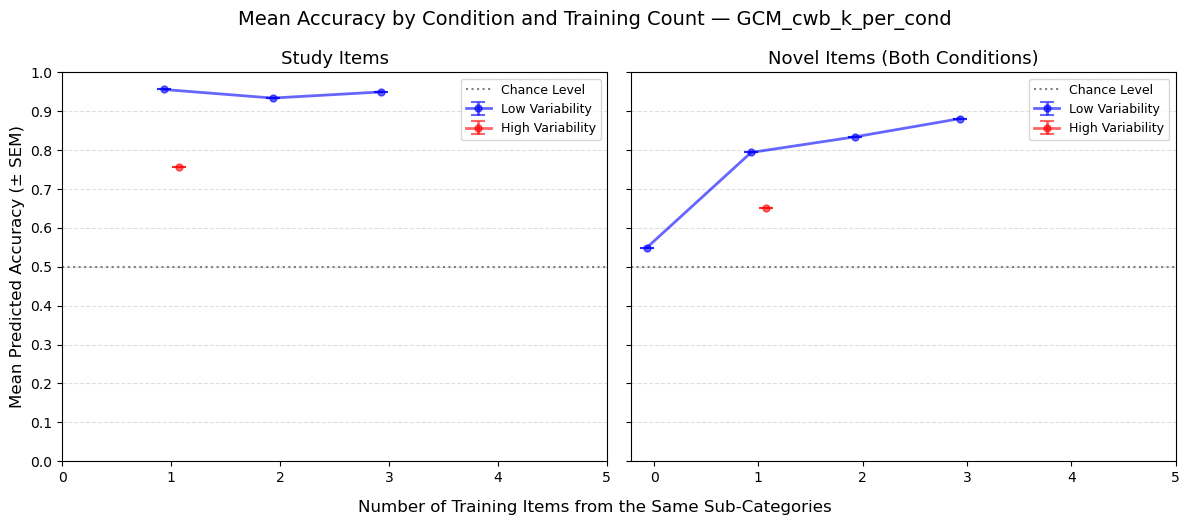

In [137]:
train_counts = compute_train_counts(data_set)   # same train counts as for observed data

for model_name, preds in all_predictions.items():
    preds['plot_df'] = prepare_model_df(preds['result_df'], filtered_data_test, train_counts)

    plot_accuracy_by_train_count(preds['plot_df'],
                                 value_col='pred_correct',
                                 model_name=model_name)

# AIC & BIC

In [129]:
# Get AIC and BIC
n_obs = len(filtered_data_test)

results = []
for name, entry in models_fits.items():
    if not entry['per_condition']:
        nll      = entry['fit'].fun
        n_params = len(entry['fit'].x)
    else:
        nll      = sum(entry['fit'][c].fun for c in ['Low', 'High'])
        n_params = sum(len(entry['fit'][c].x) for c in ['Low', 'High'])
    aic = 2 * n_params + 2 * nll
    bic = n_params * np.log(n_obs) + 2 * nll
    results.append({'Model': name, 'n_params': n_params,
                    'NLL': nll, 'AIC': aic, 'BIC': bic})

aic_bic_df = pd.DataFrame(results)

In [130]:
# all models
best_aic = aic_bic_df['AIC'].idxmin()
best_bic = aic_bic_df['BIC'].idxmin()

print(f"{'Model':<25} {'n_params':>10} {'NLL':>12} {'AIC':>12} {'BIC':>12}")
print("-" * 75)
for i, row in aic_bic_df.iterrows():
    aic_marker = ' *' if i == best_aic else '  '
    bic_marker = ' *' if i == best_bic else '  '
    print(f"{row['Model']:<25} {int(row['n_params']):>10} {row['NLL']:>12.2f} "
          f"{row['AIC']:>12.2f}{aic_marker} {row['BIC']:>12.2f}{bic_marker}")

print("\n* = best model for that metric")

Model                       n_params          NLL          AIC          BIC
---------------------------------------------------------------------------
GCM_c                              1     27052.96     54107.91       54116.70  
GCM_c_per_cond                     2     26881.67     53767.34       53784.93  
GCM_ck                             2     27105.01     54214.02       54231.60  
GCM_ck_per_cond                    4     26859.87     53727.74       53762.91  
GCM_cwb                            2     26941.03     53886.05       53903.63  
GCM_cwb_per_cond                   4     26753.65     53515.30       53550.47 *
GCM_cwb_k                          3     27009.70     54025.40       54051.78  
GCM_cwb_k_per_cond                 6     26748.28     53508.55 *     53561.31  

* = best model for that metric


In [131]:
# only single parameters across conditions models
single_aic_bic_df = aic_bic_df[~aic_bic_df.Model.str.endswith('cond')]

best_aic = single_aic_bic_df['AIC'].idxmin()
best_bic = single_aic_bic_df['BIC'].idxmin()

print(f"{'Model':<25} {'n_params':>10} {'NLL':>12} {'AIC':>12} {'BIC':>12}")
print("-" * 75)
for i, row in single_aic_bic_df.iterrows():
    aic_marker = ' *' if i == best_aic else '  '
    bic_marker = ' *' if i == best_bic else '  '
    print(f"{row['Model']:<25} {int(row['n_params']):>10} {row['NLL']:>12.2f} "
          f"{row['AIC']:>12.2f}{aic_marker} {row['BIC']:>12.2f}{bic_marker}")

print("\n* = best model for that metric")

Model                       n_params          NLL          AIC          BIC
---------------------------------------------------------------------------
GCM_c                              1     27052.96     54107.91       54116.70  
GCM_ck                             2     27105.01     54214.02       54231.60  
GCM_cwb                            2     26941.03     53886.05 *     53903.63 *
GCM_cwb_k                          3     27009.70     54025.40       54051.78  

* = best model for that metric


# Save data

In [ ]:
# Save only the variables you actually need
variables_to_save = {
    # all IDs
    'credited_subjects': credited_subjects,
}

with open("Exp2_analysis.pkl", "wb") as f:
    dill.dump(variables_to_save, f)